In [45]:
import pandas as pd
import glob
import gc
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [46]:
# =====================================================================
# PASO 0 — CONEXIÓN CON DRIVE Y CARGA DE ARCHIVOS
# =====================================================================

# Montamos Google Drive para acceder a los archivos guardados ahí
drive.mount('/content/drive')

# Ruta a la carpeta donde están todos los CSV del proyecto
RUTA = '/content/drive/MyDrive/TFM/'

# Cargamos los dos archivos que no son de Inside AIRBNB
eventos = pd.read_csv(RUTA + 'eventos_destinos_model_ready.csv')
ine = pd.read_csv(RUTA + '2083.csv', sep=';', encoding='utf-8-sig')

# Listamos (sin cargar aún) todos los calendar_* y listings_* disponibles,
# para confirmar que están todos antes de procesarlos uno a uno
calendars = sorted(glob.glob(RUTA + 'calendar_*.csv'))
listings = sorted(glob.glob(RUTA + 'listings_*.csv'))

print(f'{len(calendars)} calendar, {len(listings)} listings encontrados')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
18 calendar, 18 listings encontrados


In [47]:
# =====================================================================
# PASO 1 — REVISIÓN INICIAL DEL PRECIO (calendar_* y listings_*)
# =====================================================================

def revision_inicial(nombre, df, col_precio='price_quote_price_per_night'):
    """
    Revisión inicial de un dataset: tamaño, nulos, y estado de la columna de precio.
    El objetivo es diagnosticar antes de decidir cómo limpiar.
    """
    print(f'{"="*60}\nREVISIÓN INICIAL: {nombre}\n{"="*60}')
    print(f'Shape: {df.shape[0]} filas, {df.shape[1]} columnas\n')

    nulos = df.isna().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)
    if len(nulos) > 0:
        print('Columnas con nulos:')
        for col, n in nulos.items():
            print(f'  {col}: {n} ({100*n/len(df):.1f}%)')
    else:
        print('Sin nulos en ninguna columna.')
    print()

    resultado = {'nombre': nombre, 'filas': df.shape[0], 'columnas': df.shape[1]}

    if col_precio in df.columns:
        total = len(df)
        serie = df[col_precio]

        n_nulo = serie.isna().sum()
        n_cero = (serie == 0).sum()
        n_negativo = (serie < 0).sum()

        # La comparación (serie < p5) ya excluye los NaN por sí sola (un NaN comparado siempre da False),
        # así que restar n_nulo de nuevo no tiene sentido y daba porcentajes negativos.

        p5, p95 = serie.quantile([0.05, 0.95])
        n_outlier = ((serie < p5) | (serie > p95)).sum()

        n_valido = total - n_nulo - n_cero - n_negativo - n_outlier

        print(f'{col_precio}:')
        print(f'  Nulos: {n_nulo} ({100*n_nulo/total:.1f}%)')
        print(f'  Ceros: {n_cero} ({100*n_cero/total:.1f}%)')
        print(f'  Negativos: {n_negativo} ({100*n_negativo/total:.1f}%)')
        print(f'  Outliers (fuera P5-P95): {n_outlier} ({100*n_outlier/total:.1f}%)')
        print(f'  Utilizable: {n_valido} ({100*n_valido/total:.1f}%)')

        resultado.update({
            'pct_nulo': round(100*n_nulo/total, 1),
            'pct_cero': round(100*n_cero/total, 1),
            'pct_negativo': round(100*n_negativo/total, 1),
            'pct_outlier': round(100*n_outlier/total, 1),
            'pct_utilizable': round(100*n_valido/total, 1),
        })
    print()
    return resultado


# Ejecución sobre todos los archivos, uno a uno (para no saturar la RAM)
resumenes = []
archivos = sorted(glob.glob(RUTA + 'calendar_*.csv')) + sorted(glob.glob(RUTA + 'listings_*.csv'))

for archivo in archivos:
    nombre = archivo.split('/')[-1].replace('.csv', '')
    df_temp = pd.read_csv(archivo, low_memory=False)
    resumenes.append(revision_inicial(nombre, df_temp))
    del df_temp
    gc.collect()

tabla_revision = pd.DataFrame(resumenes)
tabla_revision


REVISIÓN INICIAL: calendar_BCN_June_2026
Shape: 5623190 filas, 5 columnas

Sin nulos en ninguna columna.


REVISIÓN INICIAL: calendar_BCN_March_2026
Shape: 5879060 filas, 5 columnas

Sin nulos en ninguna columna.


REVISIÓN INICIAL: calendar_EUSK_June_2026
Shape: 2281585 filas, 5 columnas

Sin nulos en ninguna columna.


REVISIÓN INICIAL: calendar_EUSK_March_2026
Shape: 1865515 filas, 5 columnas

Sin nulos en ninguna columna.


REVISIÓN INICIAL: calendar_GIR_June_2026
Shape: 7760996 filas, 5 columnas

Sin nulos en ninguna columna.


REVISIÓN INICIAL: calendar_GIR_March_2026
Shape: 6144411 filas, 5 columnas

Sin nulos en ninguna columna.


REVISIÓN INICIAL: calendar_MAD_June_2026
Shape: 8334782 filas, 5 columnas

Sin nulos en ninguna columna.


REVISIÓN INICIAL: calendar_MAD_March_2026
Shape: 8395763 filas, 5 columnas

Sin nulos en ninguna columna.


REVISIÓN INICIAL: calendar_MALL_June_2026
Shape: 5438865 filas, 5 columnas

Sin nulos en ninguna columna.


REVISIÓN INICIAL: calendar_MAL

,nombre,filas,columnas,pct_nulo,pct_cero,pct_negativo,pct_outlier,pct_utilizable
0,calendar_BCN_June_2026,5623190,5,NaN,NaN,NaN,NaN,NaN
1,calendar_BCN_March_2026,5879060,5,NaN,NaN,NaN,NaN,NaN
2,calendar_EUSK_June_2026,2281585,5,NaN,NaN,NaN,NaN,NaN
3,calendar_EUSK_March_2026,1865515,5,NaN,NaN,NaN,NaN,NaN
4,calendar_GIR_June_2026,7760996,5,NaN,NaN,NaN,NaN,NaN
5,calendar_GIR_March_2026,6144411,5,NaN,NaN,NaN,NaN,NaN
6,calendar_MAD_June_2026,8334782,5,NaN,NaN,NaN,NaN,NaN
7,calendar_MAD_March_2026,8395763,5,NaN,NaN,NaN,NaN,NaN
8,calendar_MALL_June_2026,5438865,5,NaN,NaN,NaN,NaN,NaN
9,calendar_MALL_March_2026,4554472,5,NaN,NaN,NaN,NaN,NaN


In [48]:
# =====================================================================
# PASO 1.1 — CLASIFICACIÓN DE CALIDAD DEL DATO
# =====================================================================
# Este umbral NO decide qué archivos se usan — todos los archivos que superan
# UMBRAL_MINIMO se utilizan igual. Aquí solo se documenta,
# dentro de los archivos ya aceptados, cuáles tienen mayor o menor respaldo de precio.

UMBRAL_MINIMO = 20  # % mínimo de precio utilizable para considerar el archivo fiable (criterio de descarte)

# La mediana se calcula sobre los archivos de listings (que sí tienen pct_utilizable),
# excluyendo los calendar y cualquier archivo ya descartado por debajo de UMBRAL_MINIMO.
valores_listings = tabla_revision.loc[
    tabla_revision['pct_utilizable'].notna() & (tabla_revision['pct_utilizable'] >= UMBRAL_MINIMO),
    'pct_utilizable'
]

# Se usa la mediana de la muestra
UMBRAL_ALTA_CALIDAD = valores_listings.median()
print(f'Umbral de alta calidad (mediana observada): {UMBRAL_ALTA_CALIDAD:.1f}%')

def clasificar_calidad(pct_utilizable):
    if pd.isna(pct_utilizable):
        return 'no aplica (calendar)'
    elif pct_utilizable < UMBRAL_MINIMO:
        return 'descartado'
    elif pct_utilizable < UMBRAL_ALTA_CALIDAD:
        return 'calidad aceptable'
    else:
        return 'alta calidad'

tabla_revision['clasificacion_calidad'] = tabla_revision['pct_utilizable'].apply(clasificar_calidad)
tabla_revision


Umbral de alta calidad (mediana observada): 78.6%


,nombre,filas,columnas,pct_nulo,pct_cero,pct_negativo,pct_outlier,pct_utilizable,clasificacion_calidad
0,calendar_BCN_June_2026,5623190,5,NaN,NaN,NaN,NaN,NaN,no aplica (calendar)
1,calendar_BCN_March_2026,5879060,5,NaN,NaN,NaN,NaN,NaN,no aplica (calendar)
2,calendar_EUSK_June_2026,2281585,5,NaN,NaN,NaN,NaN,NaN,no aplica (calendar)
3,calendar_EUSK_March_2026,1865515,5,NaN,NaN,NaN,NaN,NaN,no aplica (calendar)
4,calendar_GIR_June_2026,7760996,5,NaN,NaN,NaN,NaN,NaN,no aplica (calendar)
5,calendar_GIR_March_2026,6144411,5,NaN,NaN,NaN,NaN,NaN,no aplica (calendar)
6,calendar_MAD_June_2026,8334782,5,NaN,NaN,NaN,NaN,NaN,no aplica (calendar)
7,calendar_MAD_March_2026,8395763,5,NaN,NaN,NaN,NaN,NaN,no aplica (calendar)
8,calendar_MALL_June_2026,5438865,5,NaN,NaN,NaN,NaN,NaN,no aplica (calendar)
9,calendar_MALL_March_2026,4554472,5,NaN,NaN,NaN,NaN,NaN,no aplica (calendar)


In [49]:
# =====================================================================
# PASO 1.2 — REVISIÓN DE NULOS EN COLUMNAS CLAVE RESTANTES
# =====================================================================
# En el Paso 1 revisamos la columna de precio (nulos, ceros, negativos,
# outliers). Aquí hacemos una revisión solo de nulos
# sobre el resto de columnas que entran en el pipeline: el tipo de
# alojamiento (para segmentar por 3 tipos) y las claves de cruce entre
# listings y calendar.

def revision_inicial_columnas_clave(nombre, df, columnas_clave):
    """
    Revisión inicial de nulos, acotada solo a las columnas necesarias
    para el pipeline (no todo el archivo).
    """
    print(f'{"="*60}\nREVISIÓN INICIAL (columnas clave): {nombre}\n{"="*60}')

    columnas_presentes = [c for c in columnas_clave if c in df.columns]
    columnas_faltantes = [c for c in columnas_clave if c not in df.columns]

    if columnas_faltantes:
        print(f'Columnas esperadas pero no encontradas: {columnas_faltantes}')

    resultado = {'nombre': nombre}
    total = len(df)

    for col in columnas_presentes:
        n_nulo = df[col].isna().sum()
        print(f'{col}: {n_nulo} nulos ({100*n_nulo/total:.1f}%)')
        resultado[f'pct_nulo_{col}'] = round(100*n_nulo/total, 1)

    print()
    return resultado


# --- Listings: id, precio, fecha de cotización, tipo de alojamiento ---
# En Inside Airbnb, listings.csv usa 'id'como clave
columnas_listings = ['id', 'price_quote_price_per_night', 'price_quote_checkin_date', 'room_type']

resumenes_listings_cols = []
for archivo in sorted(glob.glob(RUTA + 'listings_*.csv')):
    nombre = archivo.split('/')[-1].replace('.csv', '')
    df_temp = pd.read_csv(archivo, low_memory=False)
    resumenes_listings_cols.append(revision_inicial_columnas_clave(nombre, df_temp, columnas_listings))
    del df_temp
    gc.collect()

tabla_columnas_listings = pd.DataFrame(resumenes_listings_cols)
tabla_columnas_listings


# --- Calendar: listing_id (clave de cruce), fecha, disponibilidad ---
columnas_calendar = ['listing_id', 'date', 'available']

resumenes_calendar_cols = []
for archivo in sorted(glob.glob(RUTA + 'calendar_*.csv')):
    nombre = archivo.split('/')[-1].replace('.csv', '')
    df_temp = pd.read_csv(archivo, low_memory=False)
    resumenes_calendar_cols.append(revision_inicial_columnas_clave(nombre, df_temp, columnas_calendar))
    del df_temp
    gc.collect()

tabla_columnas_calendar = pd.DataFrame(resumenes_calendar_cols)
tabla_columnas_calendar

REVISIÓN INICIAL (columnas clave): listings_BCN_June_2026
id: 0 nulos (0.0%)
price_quote_price_per_night: 1938 nulos (12.7%)
price_quote_checkin_date: 1631 nulos (10.7%)
room_type: 0 nulos (0.0%)

REVISIÓN INICIAL (columnas clave): listings_BCN_March_2026
id: 0 nulos (0.0%)
price_quote_price_per_night: 3378 nulos (21.0%)
price_quote_checkin_date: 3070 nulos (19.1%)
room_type: 0 nulos (0.0%)

REVISIÓN INICIAL (columnas clave): listings_EUSK_June_2026
id: 0 nulos (0.0%)
price_quote_price_per_night: 572 nulos (9.2%)
price_quote_checkin_date: 348 nulos (5.6%)
room_type: 0 nulos (0.0%)

REVISIÓN INICIAL (columnas clave): listings_EUSK_March_2026
id: 0 nulos (0.0%)
price_quote_price_per_night: 118 nulos (2.3%)
price_quote_checkin_date: 4 nulos (0.1%)
room_type: 0 nulos (0.0%)

REVISIÓN INICIAL (columnas clave): listings_GIR_June_2026
id: 0 nulos (0.0%)
price_quote_price_per_night: 4383 nulos (20.6%)
price_quote_checkin_date: 1287 nulos (6.1%)
room_type: 0 nulos (0.0%)

REVISIÓN INICIAL (colu

,nombre,pct_nulo_listing_id,pct_nulo_date,pct_nulo_available
0,calendar_BCN_June_2026,0.0,0.0,0.0
1,calendar_BCN_March_2026,0.0,0.0,0.0
2,calendar_EUSK_June_2026,0.0,0.0,0.0
3,calendar_EUSK_March_2026,0.0,0.0,0.0
4,calendar_GIR_June_2026,0.0,0.0,0.0
5,calendar_GIR_March_2026,0.0,0.0,0.0
6,calendar_MAD_June_2026,0.0,0.0,0.0
7,calendar_MAD_March_2026,0.0,0.0,0.0
8,calendar_MALL_June_2026,0.0,0.0,0.0
9,calendar_MALL_March_2026,0.0,0.0,0.0


In [50]:
df_temp = pd.read_csv(RUTA + 'listings_BCN_June_2026.csv', low_memory=False)
print(df_temp[['id', 'room_type']].isna().sum())
print(df_temp.shape)

id           0
room_type    0
dtype: int64
(15293, 90)


In [51]:
# =====================================================================
# PASO 2 — DECISIÓN DE LIMPIEZA
# =====================================================================

descartados = tabla_revision[
    (tabla_revision['pct_utilizable'].notna()) &
    (tabla_revision['pct_utilizable'] < UMBRAL_MINIMO)
]
print('Archivos descartados por precio no fiable:')
print(descartados[['nombre', 'pct_utilizable']])

Archivos descartados por precio no fiable:
                     nombre  pct_utilizable
35  listings_VAL_March_2026             0.0


In [52]:
# =====================================================================
# PASO 3 — LIMPIEZA DEL PRECIO
# =====================================================================

def limpiar_precio(df, col_precio='price_quote_price_per_night'):
    """
    Limpiamos la columna de precio de un dataset YA revisado en el Paso 1.
    """
    filas_antes = len(df)
    serie = df[col_precio]

    p5, p95 = serie.quantile([0.05, 0.95])
    mask_valido = serie.notna() & (serie > 0) & (serie >= p5) & (serie <= p95)

    df_limpio = df[mask_valido].copy()
    filas_despues = len(df_limpio)

    print(f'Filas: {filas_antes} → {filas_despues} '
          f'({filas_antes - filas_despues} eliminadas, {100*(filas_antes-filas_despues)/filas_antes:.1f}%)')

    return df_limpio

In [53]:
# =====================================================================
# PASO 4 — REVISIÓN INICIAL DE MASIFICACIÓN (available en calendar.csv)
# =====================================================================

def revision_inicial_masificacion(nombre, df, col_disponibilidad='available'):
    """
    Revisión inicial de la variable de masificación: nulos y valores
    inesperados en la columna 'available' de calendar.csv.
    """
    print(f'{"="*60}\nREVISIÓN INICIAL (masificación): {nombre}\n{"="*60}')

    resultado = {'nombre': nombre, 'filas': df.shape[0]}

    if col_disponibilidad in df.columns:
        total = len(df)
        serie = df[col_disponibilidad]

        n_nulo = serie.isna().sum()
        valores_unicos = serie.dropna().unique()
        valores_raros = [v for v in valores_unicos if v not in ('t', 'f', True, False)]

        print(f'{col_disponibilidad}: {n_nulo} nulos ({100*n_nulo/total:.1f}%)')
        print(f'Valores únicos encontrados: {valores_unicos}')
        if valores_raros:
            print(f'Valores inesperados: {valores_raros}')

        resultado.update({
            'pct_nulo_disp': round(100*n_nulo/total, 1),
            'valores_raros': str(valores_raros) if valores_raros else 'ninguno',
        })
    else:
        print(f'Columna "{col_disponibilidad}" no encontrada')
    print()
    return resultado


resumenes_masif = []
calendars = sorted(glob.glob(RUTA + 'calendar_*.csv'))

for archivo in calendars:
    nombre = archivo.split('/')[-1].replace('.csv', '')
    df_temp = pd.read_csv(archivo, low_memory=False)
    resumenes_masif.append(revision_inicial_masificacion(nombre, df_temp))
    del df_temp
    gc.collect()

tabla_masificacion = pd.DataFrame(resumenes_masif)
tabla_masificacion

REVISIÓN INICIAL (masificación): calendar_BCN_June_2026
available: 0 nulos (0.0%)
Valores únicos encontrados: ['f' 't']

REVISIÓN INICIAL (masificación): calendar_BCN_March_2026
available: 0 nulos (0.0%)
Valores únicos encontrados: ['f' 't']

REVISIÓN INICIAL (masificación): calendar_EUSK_June_2026
available: 0 nulos (0.0%)
Valores únicos encontrados: ['f' 't']

REVISIÓN INICIAL (masificación): calendar_EUSK_March_2026
available: 0 nulos (0.0%)
Valores únicos encontrados: ['f' 't']

REVISIÓN INICIAL (masificación): calendar_GIR_June_2026
available: 0 nulos (0.0%)
Valores únicos encontrados: ['f' 't']

REVISIÓN INICIAL (masificación): calendar_GIR_March_2026
available: 0 nulos (0.0%)
Valores únicos encontrados: ['f' 't']

REVISIÓN INICIAL (masificación): calendar_MAD_June_2026
available: 0 nulos (0.0%)
Valores únicos encontrados: ['f' 't']

REVISIÓN INICIAL (masificación): calendar_MAD_March_2026
available: 0 nulos (0.0%)
Valores únicos encontrados: ['f' 't']

REVISIÓN INICIAL (masifica

,nombre,filas,pct_nulo_disp,valores_raros
0,calendar_BCN_June_2026,5623190,0.0,ninguno
1,calendar_BCN_March_2026,5879060,0.0,ninguno
2,calendar_EUSK_June_2026,2281585,0.0,ninguno
3,calendar_EUSK_March_2026,1865515,0.0,ninguno
4,calendar_GIR_June_2026,7760996,0.0,ninguno
5,calendar_GIR_March_2026,6144411,0.0,ninguno
6,calendar_MAD_June_2026,8334782,0.0,ninguno
7,calendar_MAD_March_2026,8395763,0.0,ninguno
8,calendar_MALL_June_2026,5438865,0.0,ninguno
9,calendar_MALL_March_2026,4554472,0.0,ninguno


In [54]:
# =====================================================================
# PASO 5 — TRANSFORMACIÓN DE MASIFICACIÓN
# =====================================================================
# En el Paso 4 se confirmó que no habian nulos ni ningún valor inesperado en 'available'
# en los 18 archivos. Este paso solo convierte el tipo de dato de texto ('t'/'f') a booleano (True/False).

def preparar_masificacion(df, col_disponibilidad='available'):
    """
    Convierte 'available' de texto a booleano.
    """
    df_transformado = df.copy()
    df_transformado[col_disponibilidad] = df_transformado[col_disponibilidad].map({'t': True, 'f': False})

    print(f'Columna "{col_disponibilidad}" convertida a booleano. Filas: {len(df_transformado)} (sin cambios)')

    return df_transformado

In [55]:
# =====================================================================
# PASO 6 — REVISIÓN INICIAL DEL INE (2083.csv)
# =====================================================================

def revision_inicial_ine(df):
    """
    Revisión inicial del archivo del INE: nulos, duplicados, y el formato
    real de la columna 'Total'.

    El archivo trae varias filas por cada punto turístico + periodo,
    una por cada categoría de 'Establecimientos y personal
    empleado (plazas)' (ej. "Número de plazas estimadas" y otras). Por eso
    el chequeo de duplicados y nulos se hace en dos niveles: sobre el
    archivo completo (las 3 columnas) y sobre la categoría que realmente
    se usa en el proyecto ("Número de plazas estimadas") por separado ya que
    mirar solo ['Puntos turísticos', 'Periodo'] sin la categoría genera
    falsos duplicados.
    """
    print(f'{"="*60}\nREVISIÓN INICIAL: INE (2083.csv)\n{"="*60}')
    print(f'Shape: {df.shape[0]} filas, {df.shape[1]} columnas\n')

    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    print('Nulos por columna (archivo completo, todas las categorías):')
    print(nulos if len(nulos) > 0 else 'Ninguno')
    print()

    muestra = df['Total'].dropna().astype(str).head(5).tolist()
    print(f'Muestra de "Total" (texto, sin convertir): {muestra}')
    print()

    # Duplicados reales: mismo punto turístico + periodo + categoría.
    col_categoria = 'Establecimientos y personal empleado (plazas)'
    duplicados_reales = df.duplicated(subset=['Puntos turísticos', 'Periodo', col_categoria]).sum()
    print(f'Filas duplicadas reales (punto turístico + periodo + categoría): {duplicados_reales}')
    print()

    # Categorías presentes, para confirmar cuál es la más relevante en el proyecto
    print(f'Categorías encontradas en "{col_categoria}":')
    print(df[col_categoria].unique())
    print()

    # Revisión SOLO sobre la categoría relevante para el proyecto
    ine_plazas = df[df[col_categoria] == 'Número de plazas estimadas']
    nulos_plazas = ine_plazas['Total'].isna().sum()
    print(f'--- Solo categoría "Número de plazas estimadas" ---')
    print(f'Filas: {len(ine_plazas)}')
    print(f'Nulos en Total: {nulos_plazas} ({100*nulos_plazas/len(ine_plazas):.1f}%)')
    print(f'Duplicados (punto + periodo, dentro de esta categoría): '
          f'{ine_plazas.duplicated(subset=["Puntos turísticos", "Periodo"]).sum()}')
    print()

    return {
        'filas': df.shape[0],
        'nulos_total_archivo_completo': int(nulos.sum()),
        'duplicados_reales': int(duplicados_reales),
        'filas_plazas_estimadas': len(ine_plazas),
        'nulos_total_plazas_estimadas': int(nulos_plazas),
    }


revision_inicial_ine(ine)

REVISIÓN INICIAL: INE (2083.csv)
Shape: 165636 filas, 4 columnas

Nulos por columna (archivo completo, todas las categorías):
Total    66978
dtype: int64

Muestra de "Total" (texto, sin convertir): ['13.320', '13.514', '13.558', '14.046', '13.950']

Filas duplicadas reales (punto turístico + periodo + categoría): 0

Categorías encontradas en "Establecimientos y personal empleado (plazas)":
['Número de plazas estimadas' 'Número de apartamentos estimados'
 'Grado de ocupación por plazas' 'Grado de ocupación por apartamentos'
 'Grado de ocupación por apartamentos en fin de semana'
 'Personal empleado']

--- Solo categoría "Número de plazas estimadas" ---
Filas: 27606
Nulos en Total: 10832 (39.2%)
Duplicados (punto + periodo, dentro de esta categoría): 0



{'filas': 165636,
 'nulos_total_archivo_completo': 66978,
 'duplicados_reales': 0,
 'filas_plazas_estimadas': 27606,
 'nulos_total_plazas_estimadas': 10832}

In [56]:
ine_plazas = ine[ine['Establecimientos y personal empleado (plazas)'] == 'Número de plazas estimadas']

# ¿Se concentra en algunos puntos turísticos?
nulos_por_punto = ine_plazas[ine_plazas['Total'].isna()].groupby('Puntos turísticos').size().sort_values(ascending=False)
print('Puntos turísticos con más nulos:')
print(nulos_por_punto.head(20))
print()

# ¿Se concentra en algunos periodos (por ejemplo, meses más antiguos o más recientes)?
nulos_por_periodo = ine_plazas[ine_plazas['Total'].isna()].groupby('Periodo').size().sort_values(ascending=False)
print('Periodos con más nulos:')
print(nulos_por_periodo.head(20))

Puntos turísticos con más nulos:
Puntos turísticos
02007 Alcalá del Júcar           228
03099 Orihuela                   228
07003 Alcúdia                    228
06083 Mérida                     228
04100 Vera                       228
04066 Níjar                      228
46131 Gandia                     228
46181 Oliva                      228
47114 Peñafiel                   228
48020 Bilbao                     228
07024 Formentera                 228
07015 Ciutadella de Menorca      228
07026 Eivissa                    228
07048 Sant Josep de sa Talaia    228
12004 Alcalà de Xivert           228
07057 Santanyí                   228
11007 Barbate                    228
10148 Plasencia                  228
12027 Benicarló                  228
12089 Peníscola/Peñíscola        228
dtype: int64

Periodos con más nulos:
Periodo
2011M02    63
2011M01    63
2010M06    63
2010M12    62
2010M11    62
2010M10    61
2010M01    61
2011M06    61
2010M02    60
2010M03    60
2011M03    60
2010M09  

In [57]:
bilbao = ine_plazas[ine_plazas['Puntos turísticos'].str.contains('Bilbao', na=False)]

print(f'Total filas de Bilbao: {len(bilbao)}')
print(f'Nulos en Bilbao: {bilbao["Total"].isna().sum()}')
print()

# Comprobamos específicamente el rango de periodos que nos interesa (2024-2026)
bilbao_reciente = bilbao[bilbao['Periodo'].str.startswith(('2024', '2025', '2026'))]
print(f'Filas de Bilbao en 2024-2026: {len(bilbao_reciente)}')
print(f'Nulos de Bilbao en 2024-2026: {bilbao_reciente["Total"].isna().sum()}')
print(bilbao_reciente[['Periodo', 'Total']].sort_values('Periodo'))

Total filas de Bilbao: 258
Nulos en Bilbao: 228

Filas de Bilbao en 2024-2026: 30
Nulos de Bilbao en 2024-2026: 0
       Periodo  Total
30989  2024M01  1.314
30988  2024M02  1.342
30987  2024M03  1.433
30986  2024M04  1.434
30985  2024M05  1.452
30984  2024M06  1.446
30983  2024M07  1.355
30982  2024M08  1.362
30981  2024M09  1.444
30980  2024M10  1.586
30979  2024M11  1.586
30978  2024M12  1.596
30977  2025M01  1.545
30976  2025M02  1.545
30975  2025M03  1.548
30974  2025M04  1.934
30973  2025M05  1.969
30972  2025M06  1.979
30971  2025M07  1.969
30970  2025M08  1.979
30969  2025M09  1.920
30968  2025M10  1.894
30967  2025M11  1.960
30966  2025M12  2.071
30965  2026M01  2.084
30964  2026M02  1.887
30963  2026M03  2.164
30962  2026M04  2.238
30961  2026M05  2.169
30960  2026M06  2.202


In [58]:
# =====================================================================
# PASO 7 — LIMPIEZA DEL INE
# =====================================================================

def limpiar_ine(df, periodo_desde='2024M01'):
    """
    Limpiamos el dataset del INE aplicando lo detectado en el Paso 6:
    1. Filtramos las 2 categorías necesarias:
       - "Número de plazas estimadas": tamaño/capacidad, se usa como peso
         para ponderar destinos multi-punto (Euskadi, Mallorca).
       - "Grado de ocupación por plazas": la métrica real de masificación
         (% de ocupación).
       Se excluyen el resto de categorías del archivo ("Número de
       apartamentos estimados", "Personal empleado", etc.).
    2. Conviertimos 'Total' de texto a número real.
    3. Filtramos por periodo >= 2024M01: los nulos detectados en el Paso 6
       (39.2%) se concentran todos en 2010-2011, fuera del rango que usa
       el proyecto (2024-2026).
    4. Eliminamos nulos restantes y duplicados.
    """
    filas_antes = len(df)
    df_limpio = df.copy()

    # 1. Solo las dos categorías que se usan (peso + valor)
    col_categoria = 'Establecimientos y personal empleado (plazas)'
    categorias_necesarias = ['Número de plazas estimadas', 'Grado de ocupación por plazas']
    df_limpio = df_limpio[df_limpio[col_categoria].isin(categorias_necesarias)]

    # 2. Texto -> numérico
    df_limpio['Total'] = (
        df_limpio['Total'].astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .replace('nan', pd.NA)
    )
    df_limpio['Total'] = pd.to_numeric(df_limpio['Total'], errors='coerce')

    # 3. Acotar al rango de fechas real del proyecto
    df_limpio = df_limpio[df_limpio['Periodo'] >= periodo_desde]

    # 4. Nulos restantes + duplicados (no se debería eliminar nada)
    df_limpio = df_limpio[df_limpio['Total'].notna()]
    df_limpio = df_limpio.drop_duplicates(subset=['Puntos turísticos', 'Periodo', col_categoria])

    print(f'Filas: {filas_antes} → {len(df_limpio)} '
          f'({filas_antes - len(df_limpio)} eliminadas: otras categorías + fuera de rango + nulos + duplicados)')

    return df_limpio


ine_limpio = limpiar_ine(ine)

Filas: 165636 → 4590 (161046 eliminadas: otras categorías + fuera de rango + nulos + duplicados)


In [59]:
print(f'Filas en ine_limpio: {len(ine_limpio)}')
print(f'Puntos turísticos únicos: {ine_limpio["Puntos turísticos"].nunique()}')
print(f'Periodos únicos: {ine_limpio["Periodo"].nunique()}')
print(f'Rango de periodos: {ine_limpio["Periodo"].min()} a {ine_limpio["Periodo"].max()}')
print()
print(ine_limpio.head())

Filas en ine_limpio: 4590
Puntos turísticos únicos: 101
Periodos únicos: 30
Rango de periodos: 2024M01 a 2026M06

  Puntos turísticos Establecimientos y personal empleado (plazas)  Periodo  \
0       38001 Adeje                    Número de plazas estimadas  2026M06   
1       38001 Adeje                    Número de plazas estimadas  2026M05   
2       38001 Adeje                    Número de plazas estimadas  2026M04   
3       38001 Adeje                    Número de plazas estimadas  2026M03   
4       38001 Adeje                    Número de plazas estimadas  2026M02   

     Total  
0  13320.0  
1  13514.0  
2  13558.0  
3  14046.0  
4  13950.0  


In [60]:
# =====================================================================
# PASO 8 — LOCALIZAR LOS PUNTOS TURÍSTICOS DE CADA DESTINO
# =====================================================================
# El archivo del INE usa el formato "código municipio", por lo que no se
# puede adivinar el nombre exacto de cada destino a ciegas. Es por eso que
# buscaremos por texto para obtener el valor exacto tal como lo escribe el INE.

def buscar_puntos_turisticos(df, patron):
    """
    Buscamos en 'Puntos turísticos' los valores que contienen un patrón de texto.
    Sirve para identificar el nombre exacto que usa el INE para cada destino,
    antes de filtrar, evitando así el error de escribir mal un nombre y perder ese
    destino.
    """
    coincidencias = df[df['Puntos turísticos'].str.contains(patron, case=False, na=False)]
    return sorted(coincidencias['Puntos turísticos'].unique())


# Destinos de un solo punto turístico
print('Madrid:', buscar_puntos_turisticos(ine_limpio, 'Madrid'))
print('Barcelona:', buscar_puntos_turisticos(ine_limpio, 'Barcelona'))
print('Sevilla:', buscar_puntos_turisticos(ine_limpio, 'Sevilla'))
print('Málaga:', buscar_puntos_turisticos(ine_limpio, 'Málaga'))
print('Valencia:', buscar_puntos_turisticos(ine_limpio, 'València'))
print('Menorca:', buscar_puntos_turisticos(ine_limpio, 'Menorca'))
print('Girona/Torroella:', buscar_puntos_turisticos(ine_limpio, 'Torroella'))
print()

print('--- Multi-punto (Euskadi) ---')
print('Donostia:', buscar_puntos_turisticos(ine_limpio, 'Donostia'))
print('Bilbao:', buscar_puntos_turisticos(ine_limpio, 'Bilbao'))
print('Vitoria:', buscar_puntos_turisticos(ine_limpio, 'Vitoria'))
print()

print('--- Multi-punto (Mallorca) ---')
print('Palma:', buscar_puntos_turisticos(ine_limpio, 'Palma'))
print('Calvià:', buscar_puntos_turisticos(ine_limpio, 'Calvi'))
print()

# Revisamos todos los puntos turísticos, por si acaso
print('--- Todos los puntos turísticos disponibles ---')
print(sorted(ine_limpio['Puntos turísticos'].unique()))

Madrid: ['28079 Madrid']
Barcelona: ['08019 Barcelona']
Sevilla: ['41091 Sevilla']
Málaga: ['29067 Málaga']
Valencia: ['46250 València']
Menorca: ['07015 Ciutadella de Menorca']
Girona/Torroella: ['17199 Torroella de Montgrí']

--- Multi-punto (Euskadi) ---
Donostia: ['20069 Donostia/San Sebastián']
Bilbao: ['48020 Bilbao']
Vitoria: ['01059 Vitoria-Gasteiz']

--- Multi-punto (Mallorca) ---
Palma: ['07040 Palma']
Calvià: ['07011 Calvià']

--- Todos los puntos turísticos disponibles ---
['01059 Vitoria-Gasteiz', '02007 Alcalá del Júcar', "03011 Alfàs del Pi, l'", '03014 Alacant/Alicante', '03031 Benidorm', '03047 Calp', '03063 Dénia', '03082 Xàbia/Jávea', '03099 Orihuela', '03128 Teulada', '03133 Torrevieja', '04066 Níjar', '04079 Roquetas de Mar', '04100 Vera', '06083 Mérida', '07003 Alcúdia', '07011 Calvià', '07015 Ciutadella de Menorca', '07024 Formentera', '07026 Eivissa', '07040 Palma', '07048 Sant Josep de sa Talaia', '07057 Santanyí', '08019 Barcelona', '08056 Castelldefels', '100

In [61]:
# =====================================================================
# PASO 9 — FILTRADO POR DESTINO Y AGREGACIÓN MULTI-PUNTO (Euskadi, Mallorca)
# =====================================================================
# Esta tabla del INE NO es la fuente principal de masificación
# del proyecto. Se usa únicamente como VALIDACIÓN CRUZADA en el Paso 11,
# comparándola contra la masificación calculada desde calendar.csv de
# Airbnb (Paso 10), que sí es la fuente principal — cubre el 100% de las
# semanas sin los huecos estacionales que tiene el INE en destinos como
# Menorca, Girona o Mallorca fuera de temporada alta.
#
# ine_limpio contiene DOS categorías por punto turístico y periodo:
# - "Número de plazas estimadas"      -> se usa como PESO
# - "Grado de ocupación por plazas"   -> se usa como VALOR (masificación real)
#
# Para destinos de un solo punto turístico, basta con quedarse con el
# "Grado de ocupación por plazas" directamente. Para Euskadi y Mallorca
# (varios puntos), se calcula una media ponderada por plazas: cada ciudad
# pesa según su volumen real de alojamiento, no todas por igual.

col_categoria = 'Establecimientos y personal empleado (plazas)'

# Diccionario destino -> lista de puntos turísticos (nombres del Paso 8)
DESTINOS = {
    'Madrid': ['28079 Madrid'],
    'Barcelona': ['08019 Barcelona'],
    'Sevilla': ['41091 Sevilla'],
    'Malaga': ['29067 Málaga'],
    'Valencia': ['46250 València'],
    'Menorca': ['07015 Ciutadella de Menorca'],
    'Girona': ['17199 Torroella de Montgrí'],  # proxy documentado en la memoria
    'Euskadi': ['20069 Donostia/San Sebastián', '48020 Bilbao', '01059 Vitoria-Gasteiz'],
    'Mallorca': ['07040 Palma', '07011 Calvià'],
}


def calcular_masificacion_destino(df, puntos, nombre_destino):
    """
    Calculamos la serie de masificación (Grado de ocupación por plazas) para
    un destino, por periodo.
    - Si el destino tiene 1 solo punto turístico: se usa su valor directo.
    - Si tiene varios (Euskadi, Mallorca): se pondera por plazas de cada punto.
    """
    subset = df[df['Puntos turísticos'].isin(puntos)]

    plazas = subset[subset[col_categoria] == 'Número de plazas estimadas'][
        ['Puntos turísticos', 'Periodo', 'Total']
    ].rename(columns={'Total': 'plazas'})

    ocupacion = subset[subset[col_categoria] == 'Grado de ocupación por plazas'][
        ['Puntos turísticos', 'Periodo', 'Total']
    ].rename(columns={'Total': 'ocupacion'})

    combinado = plazas.merge(ocupacion, on=['Puntos turísticos', 'Periodo'], how='inner')

    if len(puntos) == 1:
        # Un solo punto: no hace falta ponderar, usamos el valor tal cual
        resultado = combinado[['Periodo', 'ocupacion']].rename(columns={'ocupacion': 'masificacion'})
    else:
        # Varios puntos: media ponderada por plazas
        combinado['ocupacion_ponderada'] = combinado['plazas'] * combinado['ocupacion']
        agregado = combinado.groupby('Periodo').agg(
            suma_ponderada=('ocupacion_ponderada', 'sum'),
            suma_plazas=('plazas', 'sum'),
        )
        agregado['masificacion'] = agregado['suma_ponderada'] / agregado['suma_plazas']
        resultado = agregado[['masificacion']].reset_index()

    resultado['destino'] = nombre_destino
    return resultado


# Ejecutamos para los 9 destinos y unimos en una sola tabla
tablas_destino = []
for destino, puntos in DESTINOS.items():
    tabla = calcular_masificacion_destino(ine_limpio, puntos, destino)
    print(f'{destino}: {len(tabla)} periodos calculados')
    tablas_destino.append(tabla)

masificacion_9_destinos = pd.concat(tablas_destino, ignore_index=True)
masificacion_9_destinos = masificacion_9_destinos[['destino', 'Periodo', 'masificacion']]
masificacion_9_destinos

Madrid: 30 periodos calculados
Barcelona: 30 periodos calculados
Sevilla: 30 periodos calculados
Malaga: 30 periodos calculados
Valencia: 30 periodos calculados
Menorca: 14 periodos calculados
Girona: 11 periodos calculados
Euskadi: 30 periodos calculados
Mallorca: 25 periodos calculados


,destino,Periodo,masificacion
0,Madrid,2026M06,61.610000
1,Madrid,2026M05,61.350000
2,Madrid,2026M04,51.090000
3,Madrid,2026M03,44.800000
4,Madrid,2026M02,45.770000
...,...,...,...
225,Mallorca,2026M02,38.280000
226,Mallorca,2026M03,29.170000
227,Mallorca,2026M04,54.710000
228,Mallorca,2026M05,63.548030


In [62]:
# Comprobación empírica: ¿en qué punto se estabiliza la ocupación diaria
# a medida que nos alejamos de la fecha de scraping? Se usa Madrid-June
# como muestra representativa, pero conviene repetirlo con 1-2 ciudades
# más para confirmar que el patrón no es propio de un solo destino.

def perfil_ocupacion_por_dia(archivo_calendar, max_dias=90):
    df = pd.read_csv(RUTA + archivo_calendar, low_memory=False)
    df = preparar_masificacion(df)
    df['date'] = pd.to_datetime(df['date'])
    fecha_scraping = df['date'].min()
    df['dias_desde_scraping'] = (df['date'] - fecha_scraping).dt.days

    perfil = (
        df[df['dias_desde_scraping'] <= max_dias]
        .groupby('dias_desde_scraping')['available']
        .apply(lambda x: 1 - x.mean())
    )
    return perfil


perfil_madrid = perfil_ocupacion_por_dia('calendar_MAD_June_2026.csv')
perfil_barcelona = perfil_ocupacion_por_dia('calendar_BCN_June_2026.csv')
perfil_sevilla = perfil_ocupacion_por_dia('calendar_SEV_June_2026.csv')

comparacion = pd.DataFrame({
    'Madrid': perfil_madrid,
    'Barcelona': perfil_barcelona,
    'Sevilla': perfil_sevilla,
})

print(comparacion.head(45))
print()
print('Media móvil de 7 días, para ver la tendencia sin ruido diario:')
print(comparacion.rolling(7).mean().iloc[::7])  # muestreamos cada 7 días para no saturar la vista

Columna "available" convertida a booleano. Filas: 8334782 (sin cambios)
Columna "available" convertida a booleano. Filas: 5623190 (sin cambios)
Columna "available" convertida a booleano. Filas: 3009792 (sin cambios)
                       Madrid  Barcelona   Sevilla
dias_desde_scraping                               
0                    0.944211   0.888936  0.784413
1                    0.782687   0.805217  0.529034
2                    0.685086   0.777599  0.448945
3                    0.670232   0.765631  0.525224
4                    0.678928   0.689912  0.532258
5                    0.756333   0.663751  0.453796
6                    0.860098   0.640353  0.449066
7                    0.829147   0.646107  0.428086
8                    0.601955   0.689381  0.405409
9                    0.543672   0.767169  0.417778
10                   0.516610   0.763988  0.430997
11                   0.562434   0.702129  0.435363
12                   0.627414   0.661820  0.385399
13                 

Columna "available" convertida a booleano. Filas: 8334782 (sin cambios)
calendar_MAD_June_2026.csv: 50 semanas calculadas
Columna "available" convertida a booleano. Filas: 8395763 (sin cambios)
calendar_MAD_March_2026.csv: 51 semanas calculadas
Columna "available" convertida a booleano. Filas: 5623190 (sin cambios)
calendar_BCN_June_2026.csv: 50 semanas calculadas
Columna "available" convertida a booleano. Filas: 5879060 (sin cambios)
calendar_BCN_March_2026.csv: 48 semanas calculadas
Columna "available" convertida a booleano. Filas: 3009792 (sin cambios)
calendar_SEV_June_2026.csv: 49 semanas calculadas
Columna "available" convertida a booleano. Filas: 2588956 (sin cambios)
calendar_SEV_March_2026.csv: 49 semanas calculadas
Columna "available" convertida a booleano. Filas: 3494115 (sin cambios)
calendar_MAL_June_2026.csv: 49 semanas calculadas
Columna "available" convertida a booleano. Filas: 2955775 (sin cambios)
calendar_MAL_March_2026.csv: 49 semanas calculadas
Columna "available" 

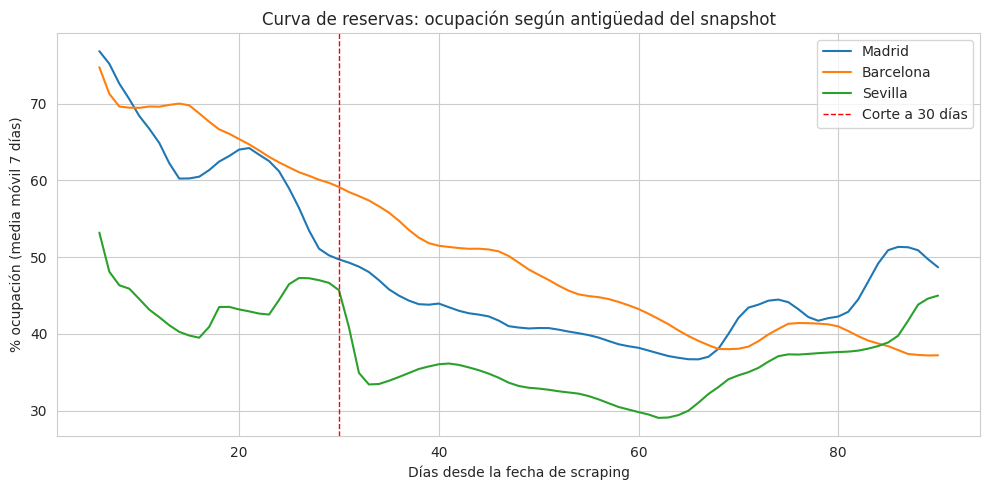

In [63]:
# =====================================================================
# PASO 10 — MASIFICACIÓN PRINCIPAL DESDE calendar.csv (POR SEMANA)
# =====================================================================
# DECISIÓN DE DISEÑO: calendar.csv (Airbnb) se usa como fuente PRINCIPAL
# de masificación, no el INE. Motivos:
# 1. Cubre el 100% de las semanas (2026-2027) sin huecos estacionales —
#    a diferencia del INE, que no encuesta bien Menorca/Girona/Mallorca
#    fuera de temporada alta (ver limitación documentada en el Paso 9).
# 2. Está en el MISMO periodo temporal que el precio (2026-2027) — no
#    hace falta usar un patrón estacional histórico como proxy del futuro.
# El INE se conserva como VALIDACIÓN CRUZADA (Paso 11), no como fuente
# principal: mide todo el mercado reglado (hoteles incluidos), mientras
# que calendar.csv solo mide el subconjunto Airbnb — son métricas
# relacionadas pero no idénticas, y así se documenta.

def calcular_masificacion_semanal_airbnb(archivo_calendar, nombre_destino, snapshot, dias_a_excluir=30):
    """
    Calcula el % de ocupación semanal (masificación) a partir de un
    calendar.csv ya preparado (available convertido a booleano).
    Ocupación = 1 - disponibilidad (available=False significa ocupado).
    Se registra el snapshot de origen (fecha de scraping) para poder
    resolver después el solape entre snapshots (Paso 10.1).

    Se excluyen los primeros `dias_a_excluir` días desde la fecha de
    scraping: se verificó empíricamente (Madrid, Barcelona, Sevilla) que
    la ocupación aparente cae de forma pronunciada y se estabiliza en una
    meseta a partir de ~día 30 — patrón consistente con el fenómeno
    documentado en Inside Airbnb de bloqueos de calendario a corto plazo
    (mantenimiento, estancias mínimas, bloqueos manuales) no relacionados
    con reservas reales. Sin este filtro, la ocupación de los días más
    cercanos al scraping queda inflada artificialmente.
    """
    df = pd.read_csv(archivo_calendar, low_memory=False)
    df = preparar_masificacion(df, col_disponibilidad='available')

    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    # Excluir los primeros N días desde la fecha de scraping (ver docstring)
    fecha_scraping = df['date'].min()
    fecha_corte = fecha_scraping + pd.Timedelta(days=dias_a_excluir)
    df = df[df['date'] >= fecha_corte]

    df['semana'] = df['date'].dt.isocalendar().week
    df['anio'] = df['date'].dt.isocalendar().year

    # % ocupación = proporción de días NO disponibles (ocupados) por semana
    resumen = (
        df.groupby(['anio', 'semana'])['available']
        .apply(lambda x: 1 - x.mean())  # available=True cuenta como libre; invertimos para tener % OCUPADO
        .reset_index(name='masificacion_airbnb')
    )
    resumen['destino'] = nombre_destino
    resumen['snapshot'] = snapshot

    return resumen


# Ejecutar para cada ciudad, uno a uno (no cargar todos los calendar.csv a la vez)
# Cada archivo se etiqueta con su snapshot ('March' o 'June') para poder
# resolver el solape de semanas entre ambos snapshots en el Paso 10.1.
CALENDAR_POR_DESTINO = {
    'Madrid': [('calendar_MAD_June_2026.csv', 'June'), ('calendar_MAD_March_2026.csv', 'March')],
    'Barcelona': [('calendar_BCN_June_2026.csv', 'June'), ('calendar_BCN_March_2026.csv', 'March')],
    'Sevilla': [('calendar_SEV_June_2026.csv', 'June'), ('calendar_SEV_March_2026.csv', 'March')],
    'Malaga': [('calendar_MAL_June_2026.csv', 'June'), ('calendar_MAL_March_2026.csv', 'March')],
    'Valencia': [('calendar_VAL_June_2026.csv', 'June'), ('calendar_VAL_March_2026.csv', 'March')],
    'Menorca': [('calendar_MEN_June_2026.csv', 'June'), ('calendar_MEN_March_2026.csv', 'March')],
    'Girona': [('calendar_GIR_June_2026.csv', 'June'), ('calendar_GIR_March_2026.csv', 'March')],
    'Euskadi': [('calendar_EUSK_June_2026.csv', 'June'), ('calendar_EUSK_March_2026.csv', 'March')],
    'Mallorca': [('calendar_MALL_June_2026.csv', 'June'), ('calendar_MALL_March_2026.csv', 'March')],
}

tablas_masificacion_airbnb = []
for destino, archivos in CALENDAR_POR_DESTINO.items():
    for archivo, snapshot in archivos:
        tabla = calcular_masificacion_semanal_airbnb(RUTA + archivo, destino, snapshot)
        tablas_masificacion_airbnb.append(tabla)
        print(f'{archivo}: {len(tabla)} semanas calculadas')
        gc.collect()

masificacion_airbnb_bruto = pd.concat(tablas_masificacion_airbnb, ignore_index=True)
masificacion_airbnb_bruto

#Curva de reservas
fig, ax = plt.subplots(figsize=(10, 5))
(comparacion.rolling(7).mean() * 100).plot(ax=ax)  # media móvil 7 días, en %
ax.axvline(30, color="red", linestyle="--", linewidth=1, label="Corte a 30 días")
ax.set_xlabel("Días desde la fecha de scraping")
ax.set_ylabel("% ocupación (media móvil 7 días)")
ax.set_title("Curva de reservas: ocupación según antigüedad del snapshot")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_curva_reservas.png", dpi=150)
plt.show()

In [64]:
# =====================================================================
# PASO 10.1 — RESOLVER SOLAPE ENTRE SNAPSHOTS (quedarse con el más reciente)
# =====================================================================
# Los snapshots de marzo y junio 2026 se solapan en gran parte de las
# semanas futuras (cada uno mira ~365 días hacia adelante desde su fecha
# de scraping). Para una misma semana, el snapshot MÁS RECIENTE (June)
# refleja mejor la ocupación real, porque a mayor proximidad a la fecha
# ya hay más reservas confirmadas en el calendario — el snapshot más
# antiguo (March) subestima sistemáticamente semanas lejanas, ya que
# aún no se habían hecho tantas reservas cuando se descargó.
# Se verificó empíricamente (Barcelona, semanas 26-35): June > March en
# todos los casos comprobados, consistente con esta explicación.

# Orden de preferencia: June antes que March
orden_snapshot = {'June': 0, 'March': 1}
masificacion_airbnb_bruto['orden_snapshot'] = masificacion_airbnb_bruto['snapshot'].map(orden_snapshot)

masificacion_airbnb = (
    masificacion_airbnb_bruto
    .sort_values('orden_snapshot')
    .drop_duplicates(subset=['destino', 'anio', 'semana'], keep='first')
    .drop(columns=['orden_snapshot'])
    .reset_index(drop=True)
)

print(f'Filas antes de resolver solape: {len(masificacion_airbnb_bruto)}')
print(f'Filas después (1 por destino-semana): {len(masificacion_airbnb)}')
masificacion_airbnb

Filas antes de resolver solape: 888
Filas después (1 por destino-semana): 560


,anio,semana,masificacion_airbnb,destino,snapshot
0,2026,40,0.490713,Madrid,June
1,2026,39,0.504970,Madrid,June
2,2026,38,0.476011,Madrid,June
3,2027,26,0.882555,Valencia,June
4,2027,25,0.602955,Valencia,June
...,...,...,...,...,...
555,2026,21,0.578093,Madrid,March
556,2026,20,0.589365,Madrid,March
557,2026,19,0.598762,Madrid,March
558,2026,18,0.650732,Madrid,March


In [65]:
for destino in masificacion_airbnb['destino'].unique():
    subset = masificacion_airbnb[masificacion_airbnb['destino'] == destino].copy()
    subset['clave'] = subset['anio'] * 100 + subset['semana']
    subset = subset.sort_values('clave')
    print(f'{destino}: {subset["clave"].min()} a {subset["clave"].max()}, {len(subset)} semanas')

Madrid: 202617 a 202726, 63 semanas
Valencia: 202618 a 202726, 62 semanas
Mallorca: 202617 a 202726, 63 semanas
Barcelona: 202617 a 202726, 63 semanas
Euskadi: 202619 a 202726, 61 semanas
Sevilla: 202618 a 202726, 62 semanas
Girona: 202618 a 202726, 62 semanas
Malaga: 202618 a 202726, 62 semanas
Menorca: 202618 a 202726, 62 semanas


Columna "available" convertida a booleano. Filas: 8334782 (sin cambios)
Columna "available" convertida a booleano. Filas: 8395763 (sin cambios)
Columna "available" convertida a booleano. Filas: 5623190 (sin cambios)
Columna "available" convertida a booleano. Filas: 5879060 (sin cambios)
Columna "available" convertida a booleano. Filas: 3009792 (sin cambios)
Columna "available" convertida a booleano. Filas: 2588956 (sin cambios)
Columna "available" convertida a booleano. Filas: 3494115 (sin cambios)
Columna "available" convertida a booleano. Filas: 2955775 (sin cambios)
Columna "available" convertida a booleano. Filas: 2870725 (sin cambios)
Columna "available" convertida a booleano. Filas: 1799450 (sin cambios)
Columna "available" convertida a booleano. Filas: 1321301 (sin cambios)
Columna "available" convertida a booleano. Filas: 1112520 (sin cambios)
Columna "available" convertida a booleano. Filas: 7760996 (sin cambios)
Columna "available" convertida a booleano. Filas: 6144411 (sin c

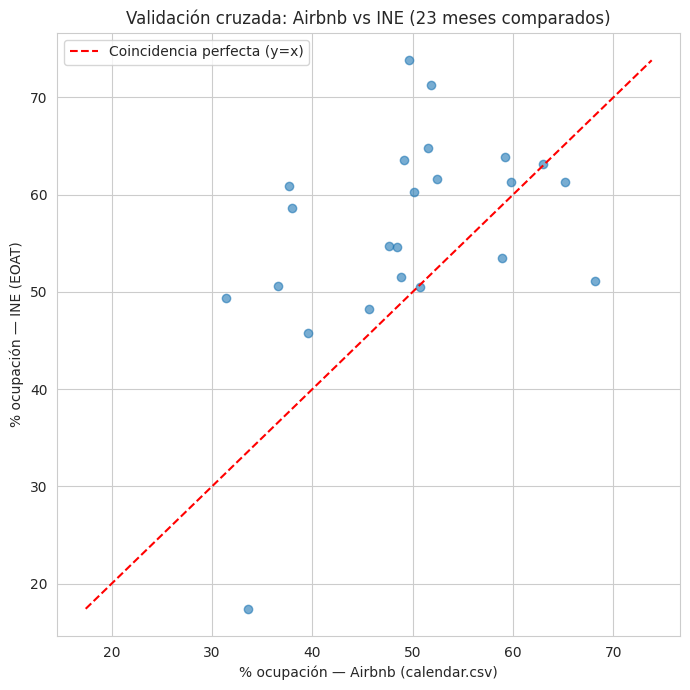

In [66]:

# =====================================================================
# PASO 11 — VALIDACIÓN CRUZADA CON EL INE
# =====================================================================
# Comparamos la masificación mensual calculada desde Airbnb con la del
# INE (Paso 9), solo para los meses donde el INE sí tiene dato, con el
# objetivo de mostrar que el patrón de Airbnb es razonablemente
# coherente con la estadística oficial.


def calcular_masificacion_mensual_airbnb(archivo_calendar, nombre_destino, snapshot, dias_a_excluir=30):
    """
    Calculamos el % de ocupación MENSUAL a partir de un calendar.csv,
    usando la fecha real de cada día (no una aproximación desde semana).
    Mismo formato de periodo que el INE ('AAAAMmm') para poder cruzar.

    Excluimos los primeros `dias_a_excluir` días desde la fecha de scraping
    (mismo criterio y justificación que en calcular_masificacion_semanal_airbnb),
    para que la validación cruzada con el INE no arrastre el sesgo de
    ocupación inflada a corto plazo.
    """
    df = pd.read_csv(archivo_calendar, low_memory=False)
    df = preparar_masificacion(df, col_disponibilidad='available')

    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    fecha_scraping = df['date'].min()
    fecha_corte = fecha_scraping + pd.Timedelta(days=dias_a_excluir)
    df = df[df['date'] >= fecha_corte]

    df['Periodo'] = df['date'].dt.strftime('%YM%m')

    resumen = (
        df.groupby('Periodo')['available']
        .apply(lambda x: 1 - x.mean())
        .reset_index(name='masificacion_airbnb')
    )
    resumen['destino'] = nombre_destino
    resumen['snapshot'] = snapshot
    return resumen


tablas_mensuales_airbnb = []
for destino, archivos in CALENDAR_POR_DESTINO.items():
    for archivo, snapshot in archivos:
        tabla = calcular_masificacion_mensual_airbnb(RUTA + archivo, destino, snapshot)
        tablas_mensuales_airbnb.append(tabla)
        gc.collect()

airbnb_mensual_bruto = pd.concat(tablas_mensuales_airbnb, ignore_index=True)

# Mismo criterio que en el Paso 10.1: quedarse con el snapshot más reciente (Junio)
# cuando un mes está cubierto por ambos snapshots.
orden_snapshot = {'June': 0, 'March': 1}
airbnb_mensual_bruto['orden_snapshot'] = airbnb_mensual_bruto['snapshot'].map(orden_snapshot)

airbnb_mensual = (
    airbnb_mensual_bruto
    .sort_values('orden_snapshot')
    .drop_duplicates(subset=['destino', 'Periodo'], keep='first')
    .drop(columns=['orden_snapshot', 'snapshot'])
    .reset_index(drop=True)
)

# Cruce con el INE (Paso 9), solo donde el INE tiene dato real
validacion = masificacion_9_destinos.merge(
    airbnb_mensual, on=['destino', 'Periodo'], how='inner'
)
validacion['masificacion_ine_pct'] = validacion['masificacion']  # ya viene en % del INE
validacion['diferencia_pp'] = validacion['masificacion_ine_pct'] - (validacion['masificacion_airbnb'] * 100)

print(f'Meses con dato en AMBAS fuentes: {len(validacion)}')
print(f'Diferencia media (puntos porcentuales): {validacion["diferencia_pp"].abs().mean():.1f}')
print(f'Diferencia máxima (puntos porcentuales): {validacion["diferencia_pp"].abs().max():.1f}')
print()
validacion[['destino', 'Periodo', 'masificacion_ine_pct', 'masificacion_airbnb', 'diferencia_pp']]

# Masificación Airbnb vs INE
fig, ax = plt.subplots(figsize=(7, 7))
x = validacion["masificacion_airbnb"] * 100  # pasar a %
y = validacion["masificacion_ine_pct"]
ax.scatter(x, y, alpha=0.6)

lim_min, lim_max = min(x.min(), y.min()), max(x.max(), y.max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], color="red", linestyle="--", label="Coincidencia perfecta (y=x)")

ax.set_xlabel("% ocupación — Airbnb (calendar.csv)")
ax.set_ylabel("% ocupación — INE (EOAT)")
ax.set_title(f"Validación cruzada: Airbnb vs INE ({len(validacion)} meses comparados)")
ax.legend()
plt.tight_layout()
plt.savefig("fig3_masificacion_airbnb_vs_ine.png", dpi=150)
plt.show()


In [67]:
for destino in masificacion_airbnb['destino'].unique():
    subset = masificacion_airbnb[masificacion_airbnb['destino'] == destino].copy()
    subset['clave'] = subset['anio'] * 100 + subset['semana']
    subset = subset.sort_values('clave')

    claves = subset['clave'].tolist()

    todas_las_semanas_posibles = set()
    anio, semana = claves[0] // 100, claves[0] % 100
    actual = claves[0]
    while actual <= claves[-1]:
        todas_las_semanas_posibles.add(actual)
        semana += 1
        if semana > 52:
            semana = 1
            anio += 1
        actual = anio * 100 + semana

    faltantes = sorted(todas_las_semanas_posibles - set(claves))

    print(f'{destino}: rango {claves[0]} a {claves[-1]}, {len(subset)} semanas cubiertas')
    if faltantes:
        print(f'  Huecos detectados: {faltantes}')
    else:
        print(f'  Sin huecos.')

Madrid: rango 202617 a 202726, 63 semanas cubiertas
  Sin huecos.
Valencia: rango 202618 a 202726, 62 semanas cubiertas
  Sin huecos.
Mallorca: rango 202617 a 202726, 63 semanas cubiertas
  Sin huecos.
Barcelona: rango 202617 a 202726, 63 semanas cubiertas
  Sin huecos.
Euskadi: rango 202619 a 202726, 61 semanas cubiertas
  Sin huecos.
Sevilla: rango 202618 a 202726, 62 semanas cubiertas
  Sin huecos.
Girona: rango 202618 a 202726, 62 semanas cubiertas
  Sin huecos.
Malaga: rango 202618 a 202726, 62 semanas cubiertas
  Sin huecos.
Menorca: rango 202618 a 202726, 62 semanas cubiertas
  Sin huecos.


In [68]:
# =====================================================================
# PASO 12 — AGREGACIÓN SEMANAL DE PRECIO POR DESTINO Y TIPO DE ALOJAMIENTO
# =====================================================================
# Objetivo: llevar el precio a la misma granularidad que la masificación
# (destino + semana), para poder cruzarlas más adelante. Se aplican los
# mismos criterios ya validados en el resto del EDA:
# - Solo precio limpio (Pasos 1-3: sin nulos/ceros/negativos/outliers).
# - La semana se calcula desde price_quote_checkin_date (fecha real de
#   la cotización), no una aproximación.
# - Igual que en masificación, listings de marzo y junio se solapan en
#   muchas semanas futuras -> se aplica el mismo criterio: se prioriza
#   el snapshot MÁS RECIENTE (June) cuando ambos cubren la misma semana,
#   por el mismo motivo (más cerca de la fecha, más reservas confirmadas
#   ya reflejadas en la cotización de precio).
# - Se excluye listings_VLC_March_2026.csv (0% precio utilizable, Paso 2).
# - Se segmenta por room_type, ya que el diseño usa 3 tipos de alojamiento.

LISTINGS_POR_DESTINO = {
    'Madrid': [('listings_MAD_June_2026.csv', 'June'), ('listings_MAD_March_2026.csv', 'March')],
    'Barcelona': [('listings_BCN_June_2026.csv', 'June'), ('listings_BCN_March_2026.csv', 'March')],
    'Sevilla': [('listings_SEV_June_2026.csv', 'June'), ('listings_SEV_March_2026.csv', 'March')],
    'Malaga': [('listings_MAL_June_2026.csv', 'June'), ('listings_MAL_March_2026.csv', 'March')],
    'Valencia': [('listings_VAL_June_2026.csv', 'June')],  # March descartado (Paso 2, 0% utilizable)
    'Menorca': [('listings_MEN_June_2026.csv', 'June'), ('listings_MEN_March_2026.csv', 'March')],
    'Girona': [('listings_GIR_June_2026.csv', 'June'), ('listings_GIR_March_2026.csv', 'March')],
    'Euskadi': [('listings_EUSK_June_2026.csv', 'June'), ('listings_EUSK_March_2026.csv', 'March')],
    'Mallorca': [('listings_MALL_June_2026.csv', 'June'), ('listings_MALL_March_2026.csv', 'March')],
}


def calcular_precio_semanal(archivo_listings, nombre_destino, snapshot):
    """
    Calcula la mediana de precio semanal por tipo de alojamiento, a partir
    de un listings.csv, usando solo las filas de precio ya limpias
    (Paso 3: limpiar_precio) y la semana real de price_quote_checkin_date.
    """
    df = pd.read_csv(archivo_listings, low_memory=False)
    df_limpio = limpiar_precio(df, col_precio='price_quote_price_per_night')

    df_limpio['price_quote_checkin_date'] = pd.to_datetime(
        df_limpio['price_quote_checkin_date'], errors='coerce'
    )
    df_limpio['semana'] = df_limpio['price_quote_checkin_date'].dt.isocalendar().week
    df_limpio['anio'] = df_limpio['price_quote_checkin_date'].dt.isocalendar().year

    resumen = (
        df_limpio.groupby(['anio', 'semana', 'room_type'])['price_quote_price_per_night']
        .median()
        .reset_index(name='precio_mediano')
    )
    resumen['destino'] = nombre_destino
    resumen['snapshot'] = snapshot

    return resumen


tablas_precio = []
for destino, archivos in LISTINGS_POR_DESTINO.items():
    for archivo, snapshot in archivos:
        print(f'Procesando {archivo}...')
        tabla = calcular_precio_semanal(RUTA + archivo, destino, snapshot)
        tablas_precio.append(tabla)
        gc.collect()

precio_semanal_bruto = pd.concat(tablas_precio, ignore_index=True)

# Resolver solape: mismo criterio que en masificación (June > March)
orden_snapshot = {'June': 0, 'March': 1}
precio_semanal_bruto['orden_snapshot'] = precio_semanal_bruto['snapshot'].map(orden_snapshot)

precio_semanal = (
    precio_semanal_bruto
    .sort_values('orden_snapshot')
    .drop_duplicates(subset=['destino', 'anio', 'semana', 'room_type'], keep='first')
    .drop(columns=['orden_snapshot'])
    .reset_index(drop=True)
)

print(f'Filas antes de resolver solape: {len(precio_semanal_bruto)}')
print(f'Filas después (1 por destino-semana-tipo): {len(precio_semanal)}')

# Se excluye 'Hotel room' (61 de 1.007 filas, ~6%) por no representar alquiler entre particulares (ver Introducción de la Memoria).
filas_antes_exclusion = len(precio_semanal)
precio_semanal = precio_semanal[precio_semanal['room_type'] != 'Hotel room'].reset_index(drop=True)
print(f'Filas tras excluir "Hotel room": {filas_antes_exclusion} → {len(precio_semanal)}')

precio_semanal



Procesando listings_MAD_June_2026.csv...
Filas: 22708 → 17266 (5442 eliminadas, 24.0%)
Procesando listings_MAD_March_2026.csv...
Filas: 23002 → 15912 (7090 eliminadas, 30.8%)
Procesando listings_BCN_June_2026.csv...
Filas: 15293 → 12024 (3269 eliminadas, 21.4%)
Procesando listings_BCN_March_2026.csv...
Filas: 16107 → 11464 (4643 eliminadas, 28.8%)
Procesando listings_SEV_June_2026.csv...
Filas: 8245 → 6881 (1364 eliminadas, 16.5%)
Procesando listings_SEV_March_2026.csv...
Filas: 7093 → 6252 (841 eliminadas, 11.9%)
Procesando listings_MAL_June_2026.csv...
Filas: 9568 → 7882 (1686 eliminadas, 17.6%)
Procesando listings_MAL_March_2026.csv...
Filas: 8098 → 6787 (1311 eliminadas, 16.2%)
Procesando listings_VAL_June_2026.csv...
Filas: 7851 → 6539 (1312 eliminadas, 16.7%)
Procesando listings_MEN_June_2026.csv...
Filas: 3620 → 2827 (793 eliminadas, 21.9%)
Procesando listings_MEN_March_2026.csv...
Filas: 3048 → 2516 (532 eliminadas, 17.5%)
Procesando listings_GIR_June_2026.csv...
Filas: 21257 →

,anio,semana,room_type,precio_mediano,destino,snapshot
0,2026,30,Entire home/apt,120.780,Madrid,June
1,2026,29,Private room,57.710,Madrid,June
2,2026,29,Entire home/apt,126.000,Madrid,June
3,2026,28,Shared room,35.000,Madrid,June
4,2026,28,Private room,63.000,Madrid,June
...,...,...,...,...,...,...
941,2026,24,Entire home/apt,420.000,Mallorca,March
942,2026,14,Entire home/apt,159.885,Madrid,March
943,2026,13,Shared room,45.000,Madrid,March
944,2026,13,Private room,85.590,Madrid,March


In [69]:
resumen_cobertura = precio_semanal.groupby('destino')['semana'].nunique().reset_index(name='semanas_unicas')
print(resumen_cobertura)
print()
print(f'Total filas: {len(precio_semanal)}')
print(f'Si todos los destinos tuvieran 3 tipos siempre: {resumen_cobertura["semanas_unicas"].sum() * 3} filas esperadas')



     destino  semanas_unicas
0  Barcelona              53
1    Euskadi              53
2     Girona              53
3     Madrid              53
4     Malaga              53
5   Mallorca              52
6    Menorca              44
7    Sevilla              50
8   Valencia              52

Total filas: 946
Si todos los destinos tuvieran 3 tipos siempre: 1389 filas esperadas


      destino        room_type  semanas
0   Barcelona  Entire home/apt       53
1   Barcelona     Private room       52
2   Barcelona      Shared room       14
3     Euskadi  Entire home/apt       51
4     Euskadi     Private room       43
5     Euskadi      Shared room        3
6      Girona  Entire home/apt       53
7      Girona     Private room       35
8      Girona      Shared room        3
9      Madrid  Entire home/apt       53
10     Madrid     Private room       53
11     Madrid      Shared room        7
12     Malaga  Entire home/apt       53
13     Malaga     Private room       36
14     Malaga      Shared room        6
15   Mallorca  Entire home/apt       52
16   Mallorca     Private room       31
17    Menorca  Entire home/apt       43
18    Menorca     Private room       22
19    Sevilla  Entire home/apt       47
20    Sevilla     Private room       32
21    Sevilla      Shared room        2
22   Valencia  Entire home/apt       52
23   Valencia     Private room       33


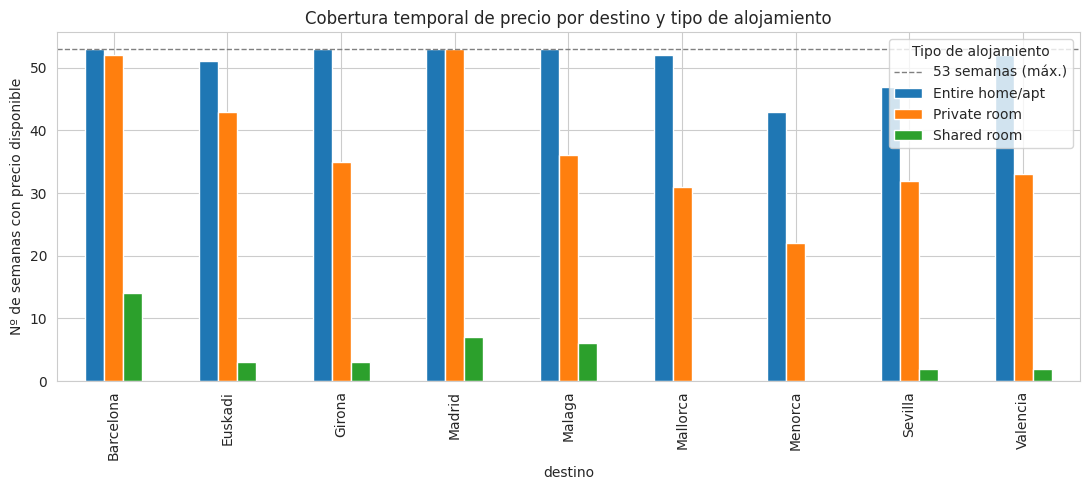

In [70]:
cobertura_detalle = precio_semanal.groupby(['destino', 'room_type'])['semana'].nunique().reset_index(name='semanas')
print(cobertura_detalle.sort_values(['destino', 'room_type']))

#COBERTURA DE PRECIO
pivot = cobertura_detalle.pivot(index="destino", columns="room_type", values="semanas").fillna(0)
ax = pivot.plot(kind="bar", figsize=(11, 5))
ax.axhline(53, color="grey", linestyle="--", linewidth=1, label="53 semanas (máx.)")
ax.set_ylabel("Nº de semanas con precio disponible")
ax.set_title("Cobertura temporal de precio por destino y tipo de alojamiento")
ax.legend(title="Tipo de alojamiento")
plt.tight_layout()
plt.savefig("fig1_cobertura_precio.png", dpi=150)
plt.show()

In [71]:
# =====================================================================
# PASO 12.1 — DOS NIVELES DE GRANULARIDAD SEGÚN COBERTURA TEMPORAL
# =====================================================================
# 'Entire home/apt' y 'Private room' tienen cobertura semanal suficiente
# (22-53 semanas de 53 según destino) para mantener granularidad SEMANAL.
# 'Shared room' tiene cobertura muy pobre (2-14 semanas, 0 en Mallorca y Menorca),
# insuficiente para desagregar por semana sin perder fiabilidad. En vez
# de excluirlo o forzar una granularidad semanal poco fiable, calcularemos a nivel de destino
# (agregando todas las semanas disponibles), reconociendo que el nivel
# de detalle del análisis no puede ser más fino que el que los datos
# realmente soportan.

# Efecto en el Pipeline posterior: para 'Shared room', el precio será constante
# dentro de cada destino en la tabla final. Es una limitación.

TIPOS_GRANULARIDAD_SEMANAL = ['Entire home/apt', 'Private room']
TIPOS_GRANULARIDAD_DESTINO = ['Shared room']

# Nivel 1: semanal, para los tipos con cobertura suficiente
precio_semanal_final = precio_semanal[
    precio_semanal['room_type'].isin(TIPOS_GRANULARIDAD_SEMANAL)
].reset_index(drop=True)

# Nivel 2: por destino (agregando todas las semanas), para Shared room
precio_shared_por_destino = (
    precio_semanal[precio_semanal['room_type'].isin(TIPOS_GRANULARIDAD_DESTINO)]
    .groupby(['destino', 'room_type'])['precio_mediano']
    .median()  # mediana de las medianas semanales disponibles
    .reset_index()
)

print(f'Precio semanal (Entire home/apt + Private room): {len(precio_semanal_final)} filas')
print(f'Precio por destino (Shared room): {len(precio_shared_por_destino)} filas de 9 posibles '
      f'(Mallorca y Menorca sin dato, como ya se detectó)')
print()
precio_shared_por_destino

Precio semanal (Entire home/apt + Private room): 909 filas
Precio por destino (Shared room): 7 filas de 9 posibles (Mallorca y Menorca sin dato, como ya se detectó)



,destino,room_type,precio_mediano
0,Barcelona,Shared room,51.250
1,Euskadi,Shared room,94.000
2,Girona,Shared room,100.605
3,Madrid,Shared room,45.000
4,Malaga,Shared room,148.500
5,Sevilla,Shared room,102.000
6,Valencia,Shared room,88.375


In [72]:
# =====================================================================
# PASO 13 — CRUCE DE PRECIO + MASIFICACIÓN (TABLA MAESTRA, POR TIPO)
# =====================================================================
# Cruzamos por destino + semana. Debido a los dos niveles de granularidad
# de precio, el cruce se hace en dos partes:
# - Entire home/apt y Private room: cruce semanal directo con masificación.
# - Shared room: el precio es constante por destino, así que se replica
#   sobre todas las semanas de masificación disponibles para ese destino
#   (el precio no varía, pero sí varía la masificación esa semana).
# Usamos 'outer'/'left' según convenga para no perder información: no
# tiene sentido un precio sin masificación, así que el cruce es 'inner' en ambos casos,
# solo se conservan combinaciones destino-semana con AMBAS variables disponibles.

# --- Parte A: Entire home/apt y Private room (cruce semanal directo) ---
tabla_semanal = precio_semanal_final.merge(
    masificacion_airbnb[['destino', 'anio', 'semana', 'masificacion_airbnb']],
    on=['destino', 'anio', 'semana'],
    how='inner'
)

# --- Parte B: Shared room (precio constante, replicado sobre las semanas
#     de masificación disponibles en ese destino) ---
tabla_shared = masificacion_airbnb[['destino', 'anio', 'semana', 'masificacion_airbnb']].merge(
    precio_shared_por_destino[['destino', 'room_type', 'precio_mediano']],
    on='destino',
    how='inner'  # solo destinos que SÍ tienen dato de Shared room (excluye Mallorca, Menorca)
)

# --- Unión de ambas partes en la tabla maestra ---
tabla_maestra = pd.concat([
    tabla_semanal[['destino', 'anio', 'semana', 'room_type', 'precio_mediano', 'masificacion_airbnb']],
    tabla_shared[['destino', 'anio', 'semana', 'room_type', 'precio_mediano', 'masificacion_airbnb']],
], ignore_index=True)

print(f'Tabla maestra (precio + masificación): {len(tabla_maestra)} filas')
print(tabla_maestra['room_type'].value_counts())
print()
tabla_maestra

Tabla maestra (precio + masificación): 1278 filas
room_type
Entire home/apt    507
Shared room        435
Private room       336
Name: count, dtype: int64



,destino,anio,semana,room_type,precio_mediano,masificacion_airbnb
0,Madrid,2026,30,Entire home/apt,120.78,0.449773
1,Madrid,2026,29,Private room,57.71,0.443303
2,Madrid,2026,29,Entire home/apt,126.00,0.443303
3,Madrid,2026,28,Private room,63.00,0.511459
4,Madrid,2026,28,Entire home/apt,141.00,0.511459
...,...,...,...,...,...,...
1273,Madrid,2026,21,Shared room,45.00,0.578093
1274,Madrid,2026,20,Shared room,45.00,0.589365
1275,Madrid,2026,19,Shared room,45.00,0.598762
1276,Madrid,2026,18,Shared room,45.00,0.650732


In [73]:
# =====================================================================
# PASO 14 — INCORPORACIÓN DE EVENTOS A LA TABLA MAESTRA
# =====================================================================
# Los destinos en eventos_destinos_model_ready.csv coinciden
# con los nombres ya usados en el resto del pipeline, no
# hace falta mapeo de nombres.
#
# Cada evento tiene un rango de fechas (fecha_inicio, fecha_fin), que
# puede abarcar más de una semana. Se expande cada evento a TODAS
# las semanas que cubre, para poder cruzarlo por destino+semana con la
# tabla maestra. Si una semana tiene más de un evento, se cuenta el
# número de eventos (no solo un flag binario), por si aporta más señal.

def expandir_evento_a_semanas(row):
    """
    Genera una fila por cada semana que cubre el rango
    fecha_inicio-fecha_fin de un evento.
    """
    fechas = pd.date_range(row['fecha_inicio'], row['fecha_fin'], freq='D')
    semanas = fechas.isocalendar()[['year', 'week']].drop_duplicates()
    semanas['destino'] = row['destino']
    semanas['evento'] = row['evento']
    return semanas


eventos['fecha_inicio'] = pd.to_datetime(eventos['fecha_inicio'], errors='coerce')
eventos['fecha_fin'] = pd.to_datetime(eventos['fecha_fin'], errors='coerce')

eventos_expandido = pd.concat(
    [expandir_evento_a_semanas(row) for _, row in eventos.iterrows()],
    ignore_index=True
)
eventos_expandido = eventos_expandido.rename(columns={'year': 'anio', 'week': 'semana'})

# Agregamos: nº de eventos por destino-semana (puede haber más de uno solapado)
eventos_por_semana = (
    eventos_expandido.groupby(['destino', 'anio', 'semana'])
    .agg(num_eventos=('evento', 'count'), eventos_nombres=('evento', lambda x: ', '.join(x)))
    .reset_index()
)

print(f'Semanas con al menos un evento: {len(eventos_por_semana)}')
print(f'Máximo de eventos solapados en una misma semana: {eventos_por_semana["num_eventos"].max()}')
print()

# --- Cruce final con la tabla maestra ---
# LEFT JOIN: no todas las semanas tienen evento, y eso es información
# válida (ausencia de evento), no un hueco a rellenar ni descartar.
tabla_final = tabla_maestra.merge(
    eventos_por_semana[['destino', 'anio', 'semana', 'num_eventos', 'eventos_nombres']],
    on=['destino', 'anio', 'semana'],
    how='left'
)

# Semanas sin evento: num_eventos debe ser 0, no NaN
tabla_final['num_eventos'] = tabla_final['num_eventos'].fillna(0).astype(int)
tabla_final['eventos_nombres'] = tabla_final['eventos_nombres'].fillna('')

print(f'Tabla final (precio + masificación + eventos): {len(tabla_final)} filas')
print(f'Filas con al menos 1 evento: {(tabla_final["num_eventos"] > 0).sum()} '
      f'({100*(tabla_final["num_eventos"] > 0).mean():.1f}%)')
print()
tabla_final

Semanas con al menos un evento: 151
Máximo de eventos solapados en una misma semana: 3

Tabla final (precio + masificación + eventos): 1278 filas
Filas con al menos 1 evento: 289 (22.6%)



,destino,anio,semana,room_type,precio_mediano,masificacion_airbnb,num_eventos,eventos_nombres
0,Madrid,2026,30,Entire home/apt,120.78,0.449773,1,Veranos de la Villa
1,Madrid,2026,29,Private room,57.71,0.443303,1,Veranos de la Villa
2,Madrid,2026,29,Entire home/apt,126.00,0.443303,1,Veranos de la Villa
3,Madrid,2026,28,Private room,63.00,0.511459,2,"Veranos de la Villa, Mad Cool Festival"
4,Madrid,2026,28,Entire home/apt,141.00,0.511459,2,"Veranos de la Villa, Mad Cool Festival"
...,...,...,...,...,...,...,...,...
1273,Madrid,2026,21,Shared room,45.00,0.578093,0,
1274,Madrid,2026,20,Shared room,45.00,0.589365,1,Fiestas de San Isidro
1275,Madrid,2026,19,Shared room,45.00,0.598762,1,Fiestas de San Isidro
1276,Madrid,2026,18,Shared room,45.00,0.650732,1,Fiestas del 2 de Mayo


Distribución del score final:
count    1278.000000
mean        0.499374
std         0.190566
min         0.087725
25%         0.340262
50%         0.506082
75%         0.640048
max         0.952705
Name: score, dtype: float64

Top 10 mejores combinaciones (score más alto):
       destino  anio  semana        room_type  precio_mediano  \
255  Barcelona  2026      52  Entire home/apt          75.655   
227  Barcelona  2026      50     Private room          42.810   
257  Barcelona  2026      51  Entire home/apt          90.780   
228  Barcelona  2026      50  Entire home/apt          91.730   
230  Barcelona  2026      49  Entire home/apt         100.130   
254  Barcelona  2026      52     Private room          46.910   
229  Barcelona  2026      49     Private room          48.500   
218  Barcelona  2026      39     Private room          40.270   
232  Barcelona  2026      48  Entire home/apt         107.000   
252  Barcelona  2026      53     Private room          46.220   

     masif

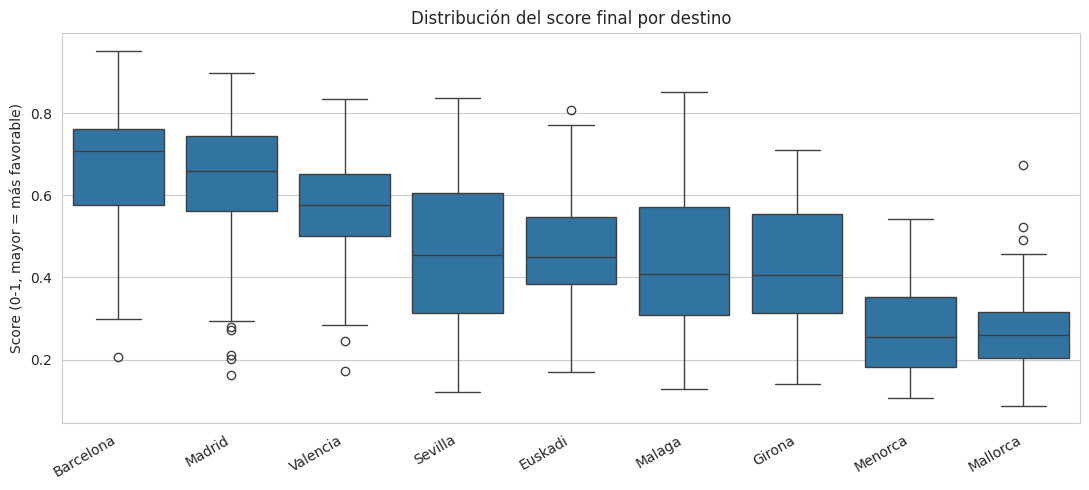

In [74]:
# =====================================================================
# PASO 15 — CÁLCULO DEL SCORE FINAL (50% precio + 30% masificación + 20% evento)
# =====================================================================
# Fórmula ya definida en el diseño del proyecto: percentiles, invertidos
# donde "menor es mejor" (precio bajo y poca masificación son mas deseables).
#
# El percentil de PRECIO se calcula POR TIPO DE ALOJAMIENTO (room_type),
# no global, debido a que los 3 tipos tienen escalas de precio estructuralmente
# distintas (un 'Shared room' a 45€ y un 'Entire home/apt' a 45€ no representan lo mismo).
# Mezclarlos en un único percentil contaminaría el ranking con diferencias de categoría,
# no de oportunidad real dentro de su tipo.
#
# La MASIFICACIÓN sí se calcula de forma global (no depende del tipo de
# alojamiento — la ocupación de un destino-semana es la misma
# independientemente de qué tipo de alojamiento se busque). Los EVENTOS
# tampoco dependen del tipo, así que también son globales.
#
# - Precio: percentil INVERTIDO, calculado POR TIPO (precio bajo dentro
#   de su categoría -> percentil alto -> mejor)
# - Masificación: percentil INVERTIDO, GLOBAL (poca ocupación -> mejor)
# - Eventos: percentil NO invertido, GLOBAL (más eventos -> mejor)

# Percentil de precio: invertido, calculado dentro de cada room_type
tabla_final['percentil_precio'] = (
    1 - tabla_final.groupby('room_type')['precio_mediano'].rank(pct=True)
)

# Percentil de masificación: invertido, global (no depende del tipo)
tabla_final['percentil_masificacion'] = 1 - tabla_final['masificacion_airbnb'].rank(pct=True)

# Percentil de eventos: NO invertido, global
tabla_final['percentil_evento'] = tabla_final['num_eventos'].rank(pct=True)

# Score final ponderado
tabla_final['score'] = (
    0.50 * tabla_final['percentil_precio'] +
    0.30 * tabla_final['percentil_masificacion'] +
    0.20 * tabla_final['percentil_evento']
)

print('Distribución del score final:')
print(tabla_final['score'].describe())
print()
print('Top 10 mejores combinaciones (score más alto):')
print(tabla_final.sort_values('score', ascending=False)[
    ['destino', 'anio', 'semana', 'room_type', 'precio_mediano', 'masificacion_airbnb', 'num_eventos', 'score']
].head(10))

# Distribución del score
orden = tabla_final.groupby("destino")["score"].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=tabla_final, x="destino", y="score", order=orden, ax=ax)
ax.set_title("Distribución del score final por destino")
ax.set_xlabel("")
ax.set_ylabel("Score (0-1, mayor = más favorable)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("fig4_distribucion_score_destino.png", dpi=150)
plt.show()

In [75]:
# Barcelona domina el Top 10 por ser mejor o por tener más filas?
print(tabla_final['destino'].value_counts())
print()
# Comparar el score medio por destino, no solo el Top 10
print(tabla_final.groupby('destino')['score'].mean().sort_values(ascending=False))

destino
Madrid       183
Barcelona    179
Girona       157
Euskadi      155
Malaga       153
Valencia     148
Sevilla      146
Mallorca      88
Menorca       69
Name: count, dtype: int64

destino
Barcelona    0.673374
Madrid       0.644153
Valencia     0.571466
Sevilla      0.466363
Euskadi      0.455622
Malaga       0.441277
Girona       0.423472
Menorca      0.275598
Mallorca     0.266840
Name: score, dtype: float64


In [76]:
# Mallorca/Menorca solo tienen semanas de temporada alta representadas?
print(tabla_final[tabla_final['destino'].isin(['Mallorca', 'Menorca'])].groupby('destino')['semana'].agg(['min', 'max', 'nunique']))
print()
print(tabla_final.groupby('destino')['masificacion_airbnb'].mean().sort_values(ascending=False))

          min  max  nunique
destino                    
Mallorca    1   53       51
Menorca     2   53       44

destino
Menorca      0.534695
Mallorca     0.506845
Madrid       0.488591
Valencia     0.474564
Girona       0.469648
Euskadi      0.465776
Sevilla      0.459111
Barcelona    0.429048
Malaga       0.428803
Name: masificacion_airbnb, dtype: float64


In [89]:
#Mejor oportunidad
mejor_oportunidad = tabla_final.sort_values('score', ascending=False).iloc[0]

print('RECOMENDACIÓN DESTACADA (mejor oportunidad global, todas las ciudades):')
print(f"  Destino: {mejor_oportunidad['destino']}")
print(f"  Semana: {int(mejor_oportunidad['semana'])} ({int(mejor_oportunidad['anio'])})")
print(f"  Tipo de alojamiento: {mejor_oportunidad['room_type']}")
print(f"  Precio mediano estimado: {mejor_oportunidad['precio_mediano']:.2f} €")
print(f"  Masificación (Airbnb): {mejor_oportunidad['masificacion_airbnb']*100:.1f} %")
print(f"  Eventos en esa semana: {int(mejor_oportunidad['num_eventos'])}")
print(f"  Score final: {mejor_oportunidad['score']:.3f}")

RECOMENDACIÓN DESTACADA (mejor oportunidad global, todas las ciudades):
  Destino: Barcelona
  Semana: 52 (2026)
  Tipo de alojamiento: Entire home/apt
  Precio mediano estimado: 75.66 €
  Masificación (Airbnb): 30.5 %
  Eventos en esa semana: 1
  Score final: 0.953


In [77]:
# =====================================================================
# PASO 16 — SPLIT TEMPORAL TRAIN/TEST
# =====================================================================
# Al ser datos ordenados en el tiempo (destino-semana), el split NO se
# hace aleatorio (mezclaría pasado y futuro, generando fuga de
# información: el modelo "vería" semanas futuras al entrenar). Se hace
# un corte temporal: las semanas más ANTIGUAS van a train, las más
# RECIENTES a test — simulando el caso real de uso (predecir precio de
# semanas futuras con lo aprendido de semanas pasadas).
#
# Se usa una clave ordenable (anio*100 + semana) para el corte, y un
# punto de corte del 80/20 sobre el rango temporal disponible (no sobre
# el número de filas, para no filtrar el mismo destino-semana a ambos
# lados si hay varias filas por semana con distinto room_type).

tabla_final['clave_temporal'] = tabla_final['anio'] * 100 + tabla_final['semana']

claves_ordenadas = sorted(tabla_final['clave_temporal'].unique())
punto_corte = claves_ordenadas[int(len(claves_ordenadas) * 0.8)]

train = tabla_final[tabla_final['clave_temporal'] < punto_corte].copy()
test = tabla_final[tabla_final['clave_temporal'] >= punto_corte].copy()

print(f'Punto de corte temporal: semana {punto_corte}')
print(f'Train: {len(train)} filas ({train["clave_temporal"].min()} a {train["clave_temporal"].max()})')
print(f'Test: {len(test)} filas ({test["clave_temporal"].min()} a {test["clave_temporal"].max()})')


Punto de corte temporal: semana 202714
Train: 1063 filas (202617 a 202713)
Test: 215 filas (202714 a 202726)


In [78]:
# =====================================================================
# PASO 17 — PREPARACIÓN DE FEATURES (VARIABLE OBJETIVO: precio_mediano)
# =====================================================================
# Features: destino, room_type (categóricas, one-hot), semana (numérica,
# captura estacionalidad), masificacion_airbnb, num_eventos.

# Para 'Shared room', el precio es constante por destino - el modelo no podrá
# aprender variación estacional de precio para ese tipo, solo lo que aporten masificación/eventos.
# Es una limitación heredada de los datos.

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score

FEATURES_CATEGORICAS = ['destino', 'room_type']
FEATURES_NUMERICAS = ['semana', 'masificacion_airbnb', 'num_eventos']
TARGET = 'precio_mediano'

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train[FEATURES_CATEGORICAS])

def preparar_features(df):
    cat_encoded = encoder.transform(df[FEATURES_CATEGORICAS])
    cat_cols = encoder.get_feature_names_out(FEATURES_CATEGORICAS)
    X_cat = pd.DataFrame(cat_encoded, columns=cat_cols, index=df.index)
    X_num = df[FEATURES_NUMERICAS].reset_index(drop=True)
    X_cat = X_cat.reset_index(drop=True)
    return pd.concat([X_num, X_cat], axis=1)

X_train = preparar_features(train)
y_train = train[TARGET].reset_index(drop=True)
X_test = preparar_features(test)
y_test = test[TARGET].reset_index(drop=True)

print(f'Features: {X_train.shape[1]} columnas')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

Features: 15 columnas
X_train: (1063, 15), X_test: (215, 15)


In [79]:
# =====================================================================
# PASO 18 — RIDGE REGRESSION (BASELINE INTERPRETABLE)
# =====================================================================

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

print('--- Ridge Regression ---')
print(f'MAE: {mean_absolute_error(y_test, pred_ridge):.2f} €')
print(f'R²: {r2_score(y_test, pred_ridge):.3f}')
print()

# Interpretabilidad: coeficientes (qué variables mueven más el precio)
coeficientes = pd.Series(ridge.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
print('Top 10 variables con mayor peso en el precio (Ridge):')
print(coeficientes.head(10))

--- Ridge Regression ---
MAE: 53.53 €
R²: 0.545

Top 10 variables con mayor peso en el precio (Ridge):
destino_Mallorca             142.839994
destino_Menorca              111.836232
masificacion_airbnb          109.032737
destino_Madrid               -74.516833
destino_Barcelona            -65.631469
destino_Valencia             -54.694826
room_type_Entire home/apt     43.661231
destino_Sevilla              -31.344098
room_type_Shared room        -24.589760
room_type_Private room       -19.071471
dtype: float64


--- Random Forest Regressor ---
MAE: 48.38 €
R²: 0.471

Top 10 variables más importantes (Random Forest):
destino_Mallorca             0.224170
semana                       0.199982
room_type_Entire home/apt    0.151244
masificacion_airbnb          0.147589
destino_Menorca              0.139201
room_type_Private room       0.055322
destino_Barcelona            0.017107
destino_Madrid               0.015452
destino_Euskadi              0.013731
destino_Girona               0.013477
dtype: float64


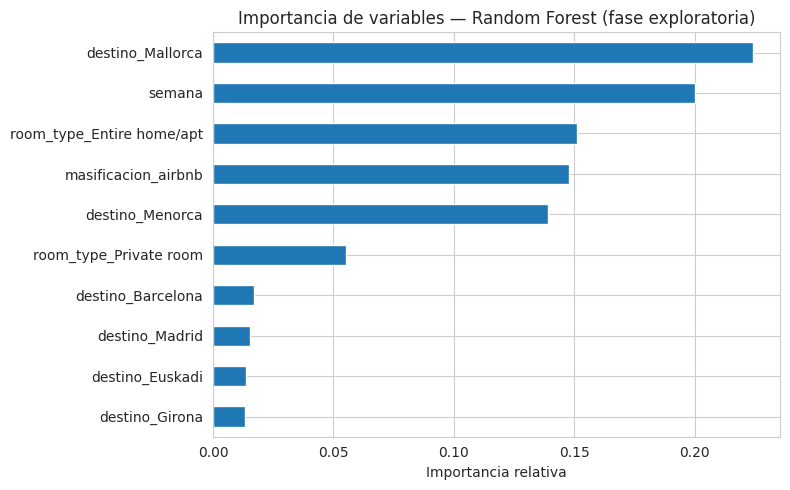

In [80]:
# =====================================================================
# PASO 19 — RANDOM FOREST REGRESSOR (NO LINEAL, FEATURE IMPORTANCE)
# =====================================================================

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print('--- Random Forest Regressor ---')
print(f'MAE: {mean_absolute_error(y_test, pred_rf):.2f} €')
print(f'R²: {r2_score(y_test, pred_rf):.3f}')
print()

importancias = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print('Top 10 variables más importantes (Random Forest):')
print(importancias.head(10))

# Importancia de variables RF

top_importancias = importancias.head(10).sort_values(ascending=True)  # top 10, orden ascendente para el barh

fig, ax = plt.subplots(figsize=(8, 5))
top_importancias.plot(kind="barh", ax=ax)
ax.set_title("Importancia de variables — Random Forest (fase exploratoria)")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.savefig("fig5_importancia_variables_rf.png", dpi=150)
plt.show()

In [81]:
# =====================================================================
# PASO 19.1 — MÉTRICAS DESGLOSADAS POR ROOM_TYPE
# =====================================================================
# El MAE/R² globales pueden estar distorsionados por
# 'Shared room': su precio es CONSTANTE por destino, así que
# el modelo no tiene ninguna variación estacional real que aprender ahí
# — solo le queda "adivinar" un valor casi fijo. Mezclar esto con
# 'Entire home/apt' y 'Private room' (que sí varían semanalmente) en una
# única métrica agregada ocultaría este efecto. Se desglosa por tipo
# para que la memoria refleje el rendimiento real de cada uno por separado.

def metricas_por_tipo(y_true, y_pred, room_types, nombre_modelo):
    resultado = []
    for tipo in room_types.unique():
        mask = (room_types == tipo).values
        if mask.sum() == 0:
            continue
        mae = mean_absolute_error(y_true[mask], y_pred[mask])
        r2 = r2_score(y_true[mask], y_pred[mask]) if mask.sum() > 1 else float('nan')
        resultado.append({'modelo': nombre_modelo, 'room_type': tipo, 'n_filas': int(mask.sum()),
                           'MAE': round(mae, 2), 'R2': round(r2, 3)})
    return pd.DataFrame(resultado)


metricas_ridge = metricas_por_tipo(y_test, pred_ridge, test['room_type'].reset_index(drop=True), 'Ridge')
metricas_rf = metricas_por_tipo(y_test, pred_rf, test['room_type'].reset_index(drop=True), 'Random Forest')

metricas_desglosadas = pd.concat([metricas_ridge, metricas_rf], ignore_index=True)
print('Métricas desglosadas por tipo de alojamiento:')
print(metricas_desglosadas.sort_values(['room_type', 'modelo']))


Métricas desglosadas por tipo de alojamiento:
          modelo        room_type  n_filas    MAE     R2
4  Random Forest  Entire home/apt       91  91.56  0.328
1          Ridge  Entire home/apt       91  80.59  0.445
3  Random Forest     Private room       33  59.31 -0.185
0          Ridge     Private room       33  58.30  0.044
5  Random Forest      Shared room       91   1.23  0.997
2          Ridge      Shared room       91  24.73  0.245


In [82]:
# =====================================================================
# PASO 20 — FUNCIÓN DE PREDICCIÓN (DETECCIÓN DE OPORTUNIDADES)
# =====================================================================
# Compara el precio REAL cotizado con el precio ESPERADO (predicho por
# el modelo, dado el contexto de estacionalidad/masificación/eventos).
# Si el precio real es más bajo de lo esperado, es una "oportunidad".

def predecir_precio(destino, semana, room_type, masificacion, num_eventos, modelo=rf):
    """
    Predice el precio esperado para una combinación destino-semana-tipo,
    dado su contexto de masificación y eventos.
    """
    fila = pd.DataFrame([{
        'destino': destino, 'room_type': room_type,
        'semana': semana, 'masificacion_airbnb': masificacion, 'num_eventos': num_eventos
    }])
    X_fila = preparar_features(fila)
    return modelo.predict(X_fila)[0]


def detectar_oportunidad(precio_real, destino, semana, room_type, masificacion, num_eventos, modelo=rf):
    """
    Compara precio real vs. precio esperado. Devuelve la diferencia
    (negativa = precio real por debajo de lo esperado = oportunidad).
    """
    precio_esperado = predecir_precio(destino, semana, room_type, masificacion, num_eventos, modelo)
    diferencia = precio_real - precio_esperado
    return {
        'precio_real': precio_real,
        'precio_esperado': round(precio_esperado, 2),
        'diferencia': round(diferencia, 2),
        'es_oportunidad': diferencia < 0,
    }


# Ejemplo de uso
ejemplo = detectar_oportunidad(
    precio_real=90, destino='Barcelona', semana=30,
    room_type='Entire home/apt', masificacion=0.45, num_eventos=1
)
print('Ejemplo de detección de oportunidad:')
print(ejemplo)

Ejemplo de detección de oportunidad:
{'precio_real': 90, 'precio_esperado': np.float64(168.18), 'diferencia': np.float64(-78.18), 'es_oportunidad': np.True_}


In [83]:
# =====================================================================
# PASO 21 — MEJORA: MODELOS SEPARADOS POR TIPO + AJUSTE DE HIPERPARÁMETROS
# =====================================================================
# El desglose del Paso 19.1 mostró que un único modelo con room_type como
# dummy da resultados flojos para Private room (R² Ridge=0.044, RF=-0.185)
# y mediocres para Entire home/apt (R²~0.33-0.45). Se prueban dos cambios:
#
# 1. MODELOS SEPARADOS por room_type: cada tipo tiene su propia dinámica
#    de precio (escala, estacionalidad) — un modelo específico por tipo
#    puede ajustarse mejor que forzar una relación común vía dummy.
# 2. AJUSTE DE HIPERPARÁMETROS con TimeSeriesSplit (no CV aleatoria, para
#    no repetir el error de fuga de información temporal que ya evitamos
#    en el split principal).
#
# 'Shared room' se excluye de esta mejora: su precio es constante por
# destino, no hay nada que un modelo más complejo pueda
# aprender ahí — se mantiene como lookup simple.

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

FEATURES_NUMERICAS_TIPO = ['semana', 'masificacion_airbnb', 'num_eventos']
FEATURES_CATEGORICAS_TIPO = ['destino']  # ya no incluye room_type: el modelo es específico de un tipo

def preparar_features_por_tipo(df, encoder_tipo):
    cat_encoded = encoder_tipo.transform(df[FEATURES_CATEGORICAS_TIPO])
    cat_cols = encoder_tipo.get_feature_names_out(FEATURES_CATEGORICAS_TIPO)
    X_cat = pd.DataFrame(cat_encoded, columns=cat_cols, index=df.index).reset_index(drop=True)
    X_num = df[FEATURES_NUMERICAS_TIPO].reset_index(drop=True)
    return pd.concat([X_num, X_cat], axis=1)


resultados_modelos_tipo = {}

for tipo in ['Entire home/apt', 'Private room']:
    print(f'\n{"="*60}\n{tipo}\n{"="*60}')

    train_tipo = train[train['room_type'] == tipo].copy()
    test_tipo = test[test['room_type'] == tipo].copy()

    encoder_tipo = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoder_tipo.fit(train_tipo[FEATURES_CATEGORICAS_TIPO])

    X_train_tipo = preparar_features_por_tipo(train_tipo, encoder_tipo)
    y_train_tipo = train_tipo[TARGET].reset_index(drop=True)
    X_test_tipo = preparar_features_por_tipo(test_tipo, encoder_tipo)
    y_test_tipo = test_tipo[TARGET].reset_index(drop=True)

    print(f'Train: {len(X_train_tipo)} filas, Test: {len(X_test_tipo)} filas')

    # --- Ridge: ajuste de alpha por TimeSeriesSplit ---
    tscv = TimeSeriesSplit(n_splits=3)
    grid_ridge = GridSearchCV(
        Ridge(), param_grid={'alpha': [0.1, 1.0, 10.0, 50.0, 100.0]},
        cv=tscv, scoring='neg_mean_absolute_error'
    )
    grid_ridge.fit(X_train_tipo, y_train_tipo)
    mejor_ridge = grid_ridge.best_estimator_
    pred_ridge_tipo = mejor_ridge.predict(X_test_tipo)

    print(f'Ridge (mejor alpha={grid_ridge.best_params_["alpha"]}): '
          f'MAE={mean_absolute_error(y_test_tipo, pred_ridge_tipo):.2f}€, '
          f'R²={r2_score(y_test_tipo, pred_ridge_tipo):.3f}')

    # --- Random Forest: ajuste de profundidad/hojas mínimas por TimeSeriesSplit ---
    grid_rf = GridSearchCV(
        RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        param_grid={'max_depth': [3, 5, 7], 'min_samples_leaf': [2, 5, 10]},
        cv=tscv, scoring='neg_mean_absolute_error'
    )
    grid_rf.fit(X_train_tipo, y_train_tipo)
    mejor_rf = grid_rf.best_estimator_
    pred_rf_tipo = mejor_rf.predict(X_test_tipo)

    print(f'Random Forest (mejores params={grid_rf.best_params_}): '
          f'MAE={mean_absolute_error(y_test_tipo, pred_rf_tipo):.2f}€, '
          f'R²={r2_score(y_test_tipo, pred_rf_tipo):.3f}')

    resultados_modelos_tipo[tipo] = {
        'ridge': mejor_ridge, 'rf': mejor_rf, 'encoder': encoder_tipo,
    }


Entire home/apt
Train: 416 filas, Test: 91 filas
Ridge (mejor alpha=0.1): MAE=85.13€, R²=0.417
Random Forest (mejores params={'max_depth': 5, 'min_samples_leaf': 5}): MAE=85.41€, R²=0.379

Private room
Train: 303 filas, Test: 33 filas
Ridge (mejor alpha=10.0): MAE=60.43€, R²=0.072
Random Forest (mejores params={'max_depth': 5, 'min_samples_leaf': 10}): MAE=53.32€, R²=0.036


In [84]:
# =====================================================================
# PASO 21.1 — MEJORA DE FEATURES: SEMANA CÍCLICA + NIVEL BASE POR DESTINO
# =====================================================================
# Dos cambios de features, no de modelo, para intentar mejorar sin más
# datos:
#
# 1. SEMANA CÍCLICA (sin/cos): un modelo lineal (Ridge) trata 'semana'
#    como si fuera una relación lineal creciente/decreciente. Pero la
#    estacionalidad es cíclica — la semana 52 está cerca de la semana 1,
#    no lejos. Sin esta corrección, Ridge no puede representar bien un
#    patrón "sube en verano, baja en invierno, vuelve a subir".
#
# 2. NIVEL BASE POR DESTINO (precio mediano histórico del destino, no
#    solo el dummy one-hot): con pocas filas por destino, el modelo
#    apenas tiene datos para "aprender" el efecto de cada dummy desde
#    cero. Dársela como feature numérica (calculada SOLO con datos de
#    TRAIN, para no filtrar información del test) le da ese nivel base
#    de golpe, dejando que el modelo se enfoque en la variación
#    ALREDEDOR de ese nivel (estacionalidad, masificación, eventos).

def anadir_features_mejoradas(df, precio_base_destino):
    df = df.copy()
    df['semana_sin'] = np.sin(2 * np.pi * df['semana'] / 52)
    df['semana_cos'] = np.cos(2 * np.pi * df['semana'] / 52)
    df['precio_base_destino'] = df['destino'].map(precio_base_destino)
    return df


import numpy as np
from sklearn.metrics import root_mean_squared_error


FEATURES_NUMERICAS_V2 = ['semana_sin', 'semana_cos', 'masificacion_airbnb', 'num_eventos', 'precio_base_destino']

resultados_modelos_v2 = {}

for tipo in ['Entire home/apt', 'Private room']:
    print(f'\n{"="*60}\n{tipo} (features mejoradas)\n{"="*60}')

    train_tipo = train[train['room_type'] == tipo].copy()
    test_tipo = test[test['room_type'] == tipo].copy()

    # Precio base por destino: SOLO con datos de train, para no filtrar
    # información del test al modelo
    precio_base_destino = train_tipo.groupby('destino')['precio_mediano'].median()

    train_tipo = anadir_features_mejoradas(train_tipo, precio_base_destino)
    test_tipo = anadir_features_mejoradas(test_tipo, precio_base_destino)

    X_train_v2 = train_tipo[FEATURES_NUMERICAS_V2]
    y_train_v2 = train_tipo[TARGET].reset_index(drop=True)
    X_test_v2 = test_tipo[FEATURES_NUMERICAS_V2]
    y_test_v2 = test_tipo[TARGET].reset_index(drop=True)

    tscv = TimeSeriesSplit(n_splits=3)

    grid_ridge_v2 = GridSearchCV(
        Ridge(), param_grid={'alpha': [0.1, 1.0, 10.0, 50.0, 100.0]},
        cv=tscv, scoring='neg_mean_absolute_error'
    )
    grid_ridge_v2.fit(X_train_v2, y_train_v2)
    pred_ridge_v2 = grid_ridge_v2.best_estimator_.predict(X_test_v2)
    rmse_ridge_v2 = root_mean_squared_error(y_test_v2, pred_ridge_v2)
    print(f'Ridge (alpha={grid_ridge_v2.best_params_["alpha"]}): '
      f'MAE={mean_absolute_error(y_test_v2, pred_ridge_v2):.2f}€, '
      f'R²={r2_score(y_test_v2, pred_ridge_v2):.3f}, '
      f'RMSE={rmse_ridge_v2:.2f}€')

    grid_rf_v2 = GridSearchCV(
        RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        param_grid={'max_depth': [3, 5, 7], 'min_samples_leaf': [2, 5, 10]},
        cv=tscv, scoring='neg_mean_absolute_error'
    )
    grid_rf_v2.fit(X_train_v2, y_train_v2)
    pred_rf_v2 = grid_rf_v2.best_estimator_.predict(X_test_v2)
    print(f'Random Forest ({grid_rf_v2.best_params_}): '
          f'MAE={mean_absolute_error(y_test_v2, pred_rf_v2):.2f}€, '
          f'R²={r2_score(y_test_v2, pred_rf_v2):.3f}')

    resultados_modelos_v2[tipo] = {
        'ridge': grid_ridge_v2.best_estimator_, 'rf': grid_rf_v2.best_estimator_,
        'precio_base_destino': precio_base_destino,
    }


Entire home/apt (features mejoradas)
Ridge (alpha=100.0): MAE=76.03€, R²=0.496, RMSE=108.17€
Random Forest ({'max_depth': 3, 'min_samples_leaf': 10}): MAE=87.23€, R²=0.387

Private room (features mejoradas)
Ridge (alpha=100.0): MAE=56.85€, R²=0.063, RMSE=103.97€
Random Forest ({'max_depth': 3, 'min_samples_leaf': 10}): MAE=54.58€, R²=-0.003


In [85]:
# =====================================================================
# PASO 21.2 — ÚLTIMO INTENTO: DUMMIES + CÍCLICA COMBINADAS + LOG(PRECIO)
# =====================================================================
# Se combinan las dos mejoras anteriores: mantener los
# dummies de destino (más información categórica que un único valor
# base) Y añadir semana cíclica. Además, se transforma el TARGET a
# log(precio): el precio suele tener distribución asimétrica (Mallorca
# 400€+ frente a otros destinos ~40-60€), y un modelo lineal ajusta mejor
# en escala logarítmica cuando hay esta asimetría. Las métricas se
# calculan siempre revirtiendo la transformación (exp) para que MAE/R²
# estén en euros reales, no en log-euros.

for tipo in ['Entire home/apt', 'Private room']:
    print(f'\n{"="*60}\n{tipo} (dummies + cíclica + log-precio)\n{"="*60}')

    train_tipo = train[train['room_type'] == tipo].copy()
    test_tipo = test[test['room_type'] == tipo].copy()

    train_tipo['semana_sin'] = np.sin(2 * np.pi * train_tipo['semana'] / 52)
    train_tipo['semana_cos'] = np.cos(2 * np.pi * train_tipo['semana'] / 52)
    test_tipo['semana_sin'] = np.sin(2 * np.pi * test_tipo['semana'] / 52)
    test_tipo['semana_cos'] = np.cos(2 * np.pi * test_tipo['semana'] / 52)

    encoder_v3 = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoder_v3.fit(train_tipo[['destino']])

    def features_v3(df, encoder=encoder_v3):
        cat = encoder.transform(df[['destino']])
        cat_cols = encoder.get_feature_names_out(['destino'])
        X_cat = pd.DataFrame(cat, columns=cat_cols, index=df.index).reset_index(drop=True)
        X_num = df[['semana_sin', 'semana_cos', 'masificacion_airbnb', 'num_eventos']].reset_index(drop=True)
        return pd.concat([X_num, X_cat], axis=1)

    X_train_v3 = features_v3(train_tipo)
    X_test_v3 = features_v3(test_tipo)

    y_train_log = np.log1p(train_tipo[TARGET].reset_index(drop=True))
    y_test_real = test_tipo[TARGET].reset_index(drop=True)

    tscv = TimeSeriesSplit(n_splits=3)
    grid_ridge_v3 = GridSearchCV(
        Ridge(), param_grid={'alpha': [0.1, 1.0, 10.0, 50.0, 100.0]},
        cv=tscv, scoring='neg_mean_absolute_error'
    )
    grid_ridge_v3.fit(X_train_v3, y_train_log)

    pred_log = grid_ridge_v3.best_estimator_.predict(X_test_v3)
    pred_real = np.expm1(pred_log)  # revertir log para volver a euros reales
    rmse_v3 = root_mean_squared_error(y_test_real, pred_real)

    print(f'Ridge log (alpha={grid_ridge_v3.best_params_["alpha"]}): '
          f'MAE={mean_absolute_error(y_test_real, pred_real):.2f}€, '
          f'R²={r2_score(y_test_real, pred_real):.3f}, '
          f'RMSE={rmse_v3:.2f}€')

    # Se guarda SOLO el resultado de Private room de esta versión (log),
    # que fue la ganadora para este tipo. Entire home/apt se queda con
    # la versión del Paso 21.1 (cíclica + precio_base_destino), que dio
    # mejor resultado (R²=0.496 vs 0.451 aquí).
    if tipo == 'Private room':
        modelo_final_private_room = {
            'modelo': grid_ridge_v3.best_estimator_,
            'encoder': encoder_v3,
            'usa_log': True,
        }


Entire home/apt (dummies + cíclica + log-precio)
Ridge log (alpha=0.1): MAE=82.07€, R²=0.451, RMSE=112.94€

Private room (dummies + cíclica + log-precio)
Ridge log (alpha=10.0): MAE=48.45€, R²=0.102, RMSE=101.82€


In [86]:
# =====================================================================
# PASO 22 — SHARED ROOM: LOOKUP SIMPLE (NO MODELO)
# =====================================================================
# 'Shared room' tiene precio constante por destino (Paso 12.1) — no hay
# estacionalidad real que un modelo pueda aprender (confirmado en el
# Paso 19.1: R²=0.997 con Random Forest es trivial, no un logro real).

precio_lookup_shared_room = precio_shared_por_destino.set_index('destino')['precio_mediano'].to_dict()
print('Lookup de precio para Shared room (por destino):')
print(precio_lookup_shared_room)

Lookup de precio para Shared room (por destino):
{'Barcelona': 51.25, 'Euskadi': 94.0, 'Girona': 100.60499999999999, 'Madrid': 45.0, 'Malaga': 148.5, 'Sevilla': 102.0, 'Valencia': 88.375}


In [87]:
# =====================================================================
# PASO 23 — CONSOLIDACIÓN FINAL: MODELO GANADOR POR TIPO + PREDICCIÓN ÚNICA
# =====================================================================
# Resumen de qué modelo se usa para cada tipo, y por qué (mejor resultado
# de todos los enfoques probados en los Pasos 18-21.2):
#
# - Entire home/apt -> Ridge (cíclica + precio_base_destino, Paso 21.1)
#   R²=0.496, MAE=76.03€ — mejor resultado de las 4 versiones probadas.
# - Private room -> Ridge (dummies + cíclica + log-precio, Paso 21.2)
#   R²=0.102, MAE=48.45€ — mejor resultado, aunque limitado por tamaño
#   de muestra (303 filas train / 33 test); documentado como limitación.
# - Shared room -> lookup directo (Paso 22), sin modelo: su precio es
#   constante por destino, un modelo no aporta nada sobre un lookup.

# Modelo ganador de Entire home/apt (del Paso 21.1, ya calculado)
modelo_final_entire_home = resultados_modelos_v2['Entire home/apt']

def predecir_precio_final(destino, semana, room_type, masificacion, num_eventos):
    """
    Función de predicción única del proyecto: enruta a la estrategia
    correcta según el tipo de alojamiento (modelo Ridge específico,
    o lookup directo para Shared room).
    """
    semana_sin = np.sin(2 * np.pi * semana / 52)
    semana_cos = np.cos(2 * np.pi * semana / 52)

    if room_type == 'Shared room':
        precio = precio_lookup_shared_room.get(destino)
        if precio is None:
            return None  # destino sin dato de Shared room (Mallorca, Menorca)
        return round(precio, 2)

    elif room_type == 'Entire home/apt':
        modelo = modelo_final_entire_home['ridge']
        precio_base = modelo_final_entire_home['precio_base_destino'].get(destino)
        X = pd.DataFrame([{
            'semana_sin': semana_sin, 'semana_cos': semana_cos,
            'masificacion_airbnb': masificacion, 'num_eventos': num_eventos,
            'precio_base_destino': precio_base,
        }])
        return round(modelo.predict(X)[0], 2)

    elif room_type == 'Private room':
        modelo = modelo_final_private_room['modelo']
        encoder = modelo_final_private_room['encoder']
        cat = encoder.transform(pd.DataFrame([{'destino': destino}]))
        cat_cols = encoder.get_feature_names_out(['destino'])
        X_cat = pd.DataFrame(cat, columns=cat_cols)
        X_num = pd.DataFrame([{
            'semana_sin': semana_sin, 'semana_cos': semana_cos,
            'masificacion_airbnb': masificacion, 'num_eventos': num_eventos,
        }])
        X = pd.concat([X_num, X_cat], axis=1)
        pred_log = modelo.predict(X)[0]
        return round(np.expm1(pred_log), 2)

    else:
        raise ValueError(f'room_type desconocido: {room_type}')


def detectar_oportunidad_final(precio_real, destino, semana, room_type, masificacion, num_eventos):
    """
    Compara precio real vs. precio esperado (predecir_precio_final).
    Negativo = precio real por debajo de lo esperado = oportunidad.
    """
    precio_esperado = predecir_precio_final(destino, semana, room_type, masificacion, num_eventos)
    if precio_esperado is None:
        return {'error': f'Sin modelo/dato disponible para {room_type} en {destino}'}
    diferencia = precio_real - precio_esperado
    return {
        'precio_real': precio_real,
        'precio_esperado': precio_esperado,
        'diferencia': round(diferencia, 2),
        'es_oportunidad': diferencia < 0,
    }


# --- Ejemplos de uso, uno por cada tipo, para confirmar que todo funciona ---
print('\n--- Ejemplos de predicción final ---')
print(detectar_oportunidad_final(90, 'Barcelona', 30, 'Entire home/apt', 0.45, 1))
print(detectar_oportunidad_final(55, 'Madrid', 20, 'Private room', 0.55, 0))
print(detectar_oportunidad_final(40, 'Sevilla', 15, 'Shared room', 0.50, 0))
print(detectar_oportunidad_final(60, 'Mallorca', 25, 'Shared room', 0.50, 0))  # sin dato -> error esperado


--- Ejemplos de predicción final ---
{'precio_real': 90, 'precio_esperado': np.float64(138.76), 'diferencia': np.float64(-48.76), 'es_oportunidad': np.True_}
{'precio_real': 55, 'precio_esperado': np.float64(69.32), 'diferencia': np.float64(-14.32), 'es_oportunidad': np.True_}
{'precio_real': 40, 'precio_esperado': 102.0, 'diferencia': -62.0, 'es_oportunidad': True}
{'error': 'Sin modelo/dato disponible para Shared room en Mallorca'}
